<a href="https://colab.research.google.com/github/idarlandias/Fundamentos-de-Mineracao-de-Dados/blob/main/Lista_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# Célula 1: Instalação de bibliotecas
!pip install fitter

In [18]:
import pandas as pd

# Carregando o dataset
df = pd.read_csv('fakeTelegram.BR_2022.csv')

# Visualizando as primeiras linhas do dataframe
print(df.head())

/tmp/ipython-input-1221018080.py:4: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('fakeTelegram.BR_2022.csv')


          date_message               id_member_anonymous  \
0  2022-10-05 06:25:04  1078cc958f0febe28f4d03207660715f   
1  2022-10-05 06:25:08                               NaN   
2  2022-10-05 06:26:28  92a2d8fd7144074f659d1d29dc3751da   
3  2022-10-05 06:27:28  d60aa38f62b4977426b70944af4aff72   
4  2022-10-05 06:27:44  cd6979b0b5265f08468fa1689b6300ce   

                 id_group_anonymous                                 media  \
0  12283e08a2eb5789201e105b34489ee7                                   NaN   
1  12283e08a2eb5789201e105b34489ee7                                   NaN   
2  9f2d7394334eb224c061c9740b5748fc                                   NaN   
3  c8f2de56550ed0bf85249608b7ead93d  94dca4cda503100ebfda7ce2bcc060eb.jpg   
4  e56ec342fc599ebb4ed89655eb6f03aa  5ad5c8bbe9da93a37fecf3e5aa5b0637.jpg   

  media_type media_url has_media has_media_url trava_zap  \
0        NaN       NaN     False         False     False   
1        NaN       NaN     False         False     False

In [23]:
# Célula 3: Remover Trava-zaps
import re

# Função para identificar possíveis trava-zaps
def is_travazap(text):
    if isinstance(text, str):
        # Condição 1: Texto muito longo
        if len(text) > 2500:
            return True
        # Condição 2: Alta proporção de caracteres não alfanuméricos em textos de tamanho moderado
        non_alnum_count = len(re.findall(r'[^a-zA-Z0-9\s]', text))
        text_len = len(text)
        if text_len > 100 and (non_alnum_count / text_len) > 0.6:
            return True
    return False

# Aplicando a função na coluna correta ('text_content_anonymous')
df_sem_travazap = df[~df['text_content_anonymous'].apply(is_travazap)].copy()

print(f"Formato antes da remoção de trava-zaps: {df.shape}")
print(f"Formato após a remoção de trava-zaps: {df_sem_travazap.shape}")

# Atualizamos nosso dataframe principal
df = df_sem_travazap

Formato antes da remoção de trava-zaps: (341966, 19)
Formato após a remoção de trava-zaps: (339507, 19)


In [24]:
# Célula 4: Remover Linhas Duplicadas

shape_antes = df.shape
df.drop_duplicates(inplace=True)
shape_depois = df.shape

print(f"Formato antes da remoção de duplicadas: {shape_antes}")
print(f"Formato após a remoção de duplicadas: {shape_depois}")

Formato antes da remoção de duplicadas: (339507, 19)
Formato após a remoção de duplicadas: (339507, 19)


In [25]:
# Célula 5: Remover Textos Curtos

shape_antes = df.shape

# Remove linhas onde o texto é nulo na coluna correta ('text_content_anonymous')
df = df.dropna(subset=['text_content_anonymous'])
# Filtra textos curtos na coluna correta ('text_content_anonymous')
df = df[df['text_content_anonymous'].astype(str).str.split().str.len() >= 5]

shape_depois = df.shape

print(f"Formato antes da remoção de textos curtos: {shape_antes}")
print(f"Formato após a remoção de textos curtos: {shape_depois}")

Formato antes da remoção de textos curtos: (339507, 19)
Formato após a remoção de textos curtos: (197104, 19)


Colunas numéricas identificadas: ['dataset_info_id', 'score_sentiment', 'score_misinformation', 'id_message']

 ANÁLISE DO ATRIBUTO: 'dataset_info_id'

1. Medidas de Tendência Central:
   - Média: 5.00
   - Mediana: 5.00
   - Moda: 5.0

2. Medidas de Variabilidade:
   - Variância: 0.00
   - Desvio Padrão: 0.00
   - Amplitude (Range): 0.00

3. Histograma:


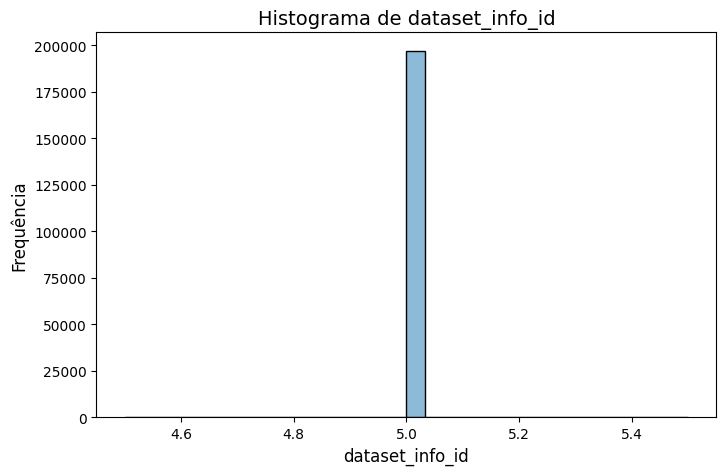


4. Boxplot:


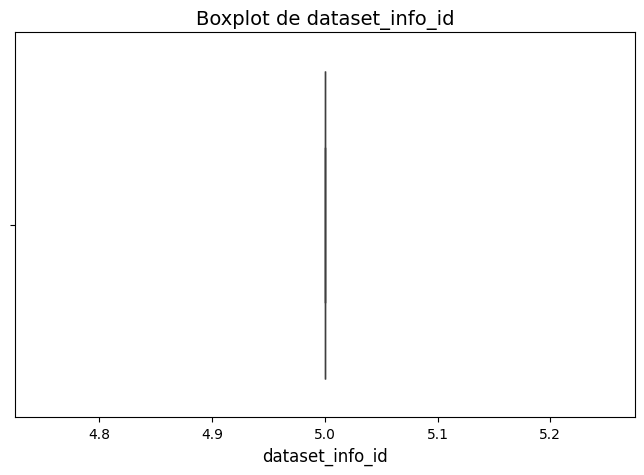


5. QQ-Plot (Gráfico de Probabilidade Normal):


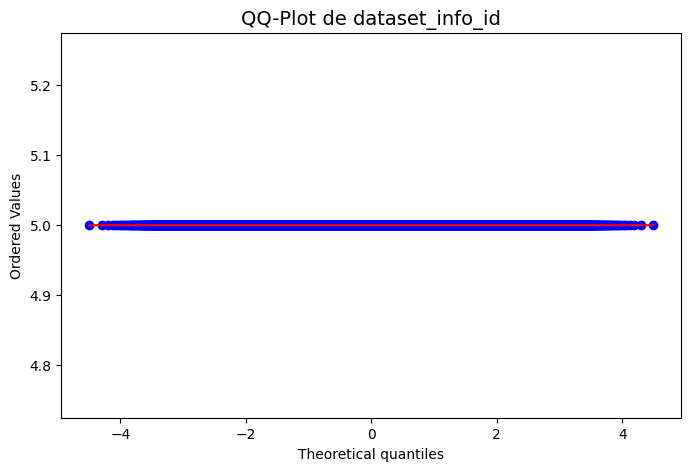


6. Teste de Normalidade (Shapiro-Wilk):
   - Estatística do teste = 1.000
   - p-valor = 1.000
   - Conclusão: Não há evidências para rejeitar a hipótese de normalidade (p > 0.05).

7. Verificação da Melhor Distribuição de Ajuste:


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 197104.
  res = hypotest_fun_out(*samples, **kwds)


          sumsquare_error          aic           bic  kl_div  ks_statistic  \
chi2          8903.456279          inf           inf     inf      1.000000   
cauchy       10000.000000  9993.393095  1.001378e+04     inf      0.500000   
exponpow     10000.000000          inf           inf     NaN      0.775175   
lognorm      10000.000000          inf           inf     inf      0.540506   
powerlaw     10000.000000          inf           inf     NaN      0.999994   

          ks_pvalue  
chi2            0.0  
cauchy          0.0  
exponpow        0.0  
lognorm         0.0  
powerlaw        0.0  



 ANÁLISE DO ATRIBUTO: 'score_sentiment'

1. Medidas de Tendência Central:
   - Média: 0.02
   - Mediana: 0.00
   - Moda: 0.0

2. Medidas de Variabilidade:
   - Variância: 0.28
   - Desvio Padrão: 0.53
   - Amplitude (Range): 2.00

3. Histograma:


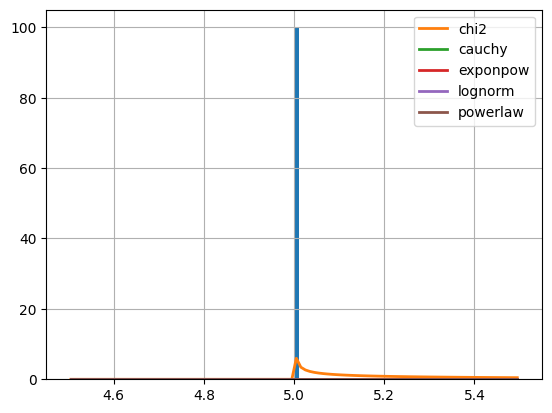

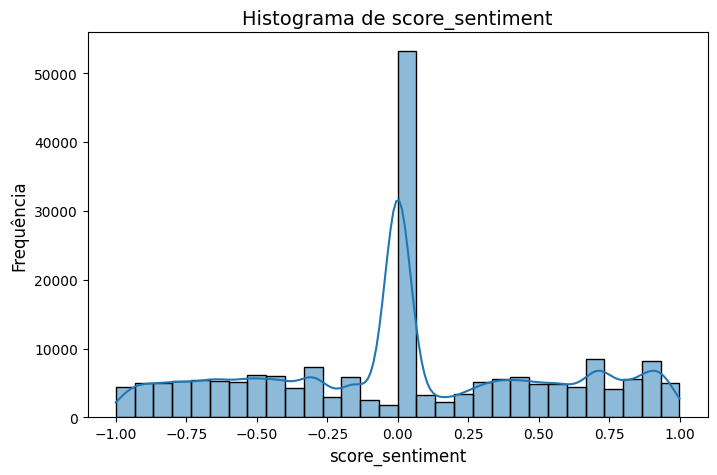


4. Boxplot:


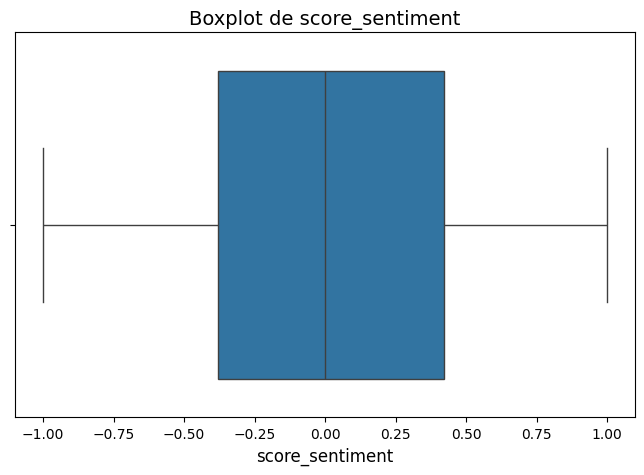


5. QQ-Plot (Gráfico de Probabilidade Normal):


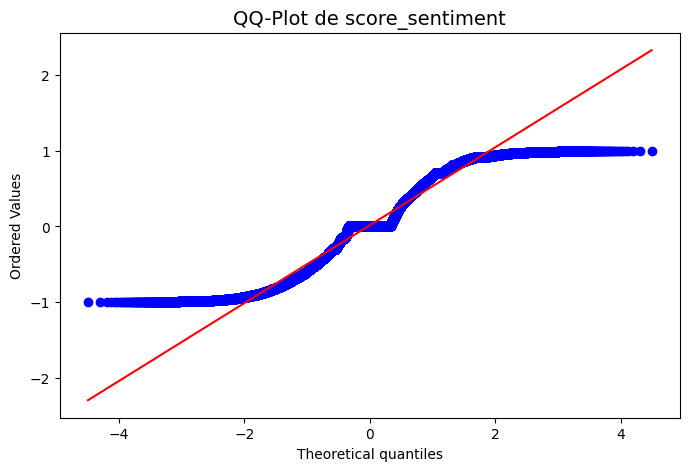


6. Teste de Normalidade (Shapiro-Wilk):
   - Estatística do teste = 0.959
   - p-valor = 0.000
   - Conclusão: A hipótese de normalidade é rejeitada (p <= 0.05).

7. Verificação da Melhor Distribuição de Ajuste:


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 197070.
  res = hypotest_fun_out(*samples, **kwds)


          sumsquare_error         aic         bic    kl_div  ks_statistic  \
cauchy         161.797549  244.202806  264.585435  0.880331      0.134951   
exponpow       162.989545  165.863940  196.437883  0.543851      0.132441   
lognorm        163.026351  181.818817  212.392760  0.618277      0.137284   
gamma          163.030546  181.766428  212.340371  0.618239      0.139520   
norm           163.036597  179.738537  200.121166  0.618214      0.141272   

          ks_pvalue  
cauchy          0.0  
exponpow        0.0  
lognorm         0.0  
gamma           0.0  
norm            0.0  



 ANÁLISE DO ATRIBUTO: 'score_misinformation'

1. Medidas de Tendência Central:
   - Média: 0.29
   - Mediana: 0.17
   - Moda: 0.1106282729517939

2. Medidas de Variabilidade:
   - Variância: 0.08
   - Desvio Padrão: 0.28
   - Amplitude (Range): 1.00

3. Histograma:


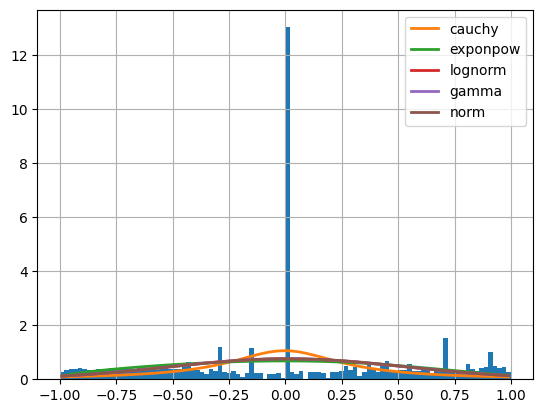

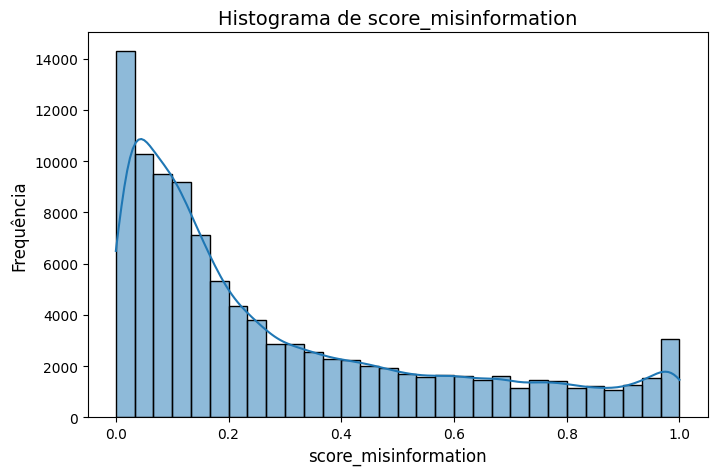


4. Boxplot:


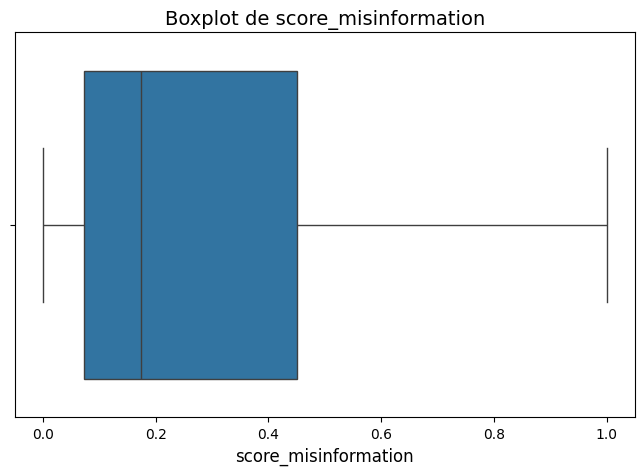


5. QQ-Plot (Gráfico de Probabilidade Normal):


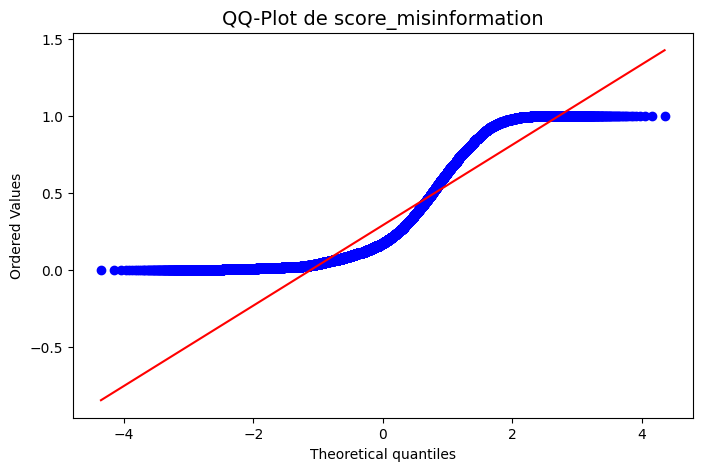


6. Teste de Normalidade (Shapiro-Wilk):
   - Estatística do teste = 0.845
   - p-valor = 0.000
   - Conclusão: A hipótese de normalidade é rejeitada (p <= 0.05).

7. Verificação da Melhor Distribuição de Ajuste:


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 103662.
  res = hypotest_fun_out(*samples, **kwds)


          sumsquare_error         aic         bic    kl_div  ks_statistic  \
chi2            17.734394  104.066040  132.712713  0.063394      0.043788   
gamma           17.747730  104.101076  132.747749  0.063767      0.044661   
lognorm         18.173362  136.329592  164.976265  0.069099      0.063230   
expon           18.825303  100.374393  119.472175  0.067492      0.053490   
exponpow        33.646479   63.764435   92.411108  0.079078      0.162758   

              ks_pvalue  
chi2      3.747148e-173  
gamma     4.153203e-180  
lognorm    0.000000e+00  
expon     3.157134e-258  
exponpow   0.000000e+00  



 ANÁLISE DO ATRIBUTO: 'id_message'

1. Medidas de Tendência Central:
   - Média: 371242.50
   - Mediana: 53952.50
   - Moda: 1014.0

2. Medidas de Variabilidade:
   - Variância: 214969094279.66
   - Desvio Padrão: 463647.60
   - Amplitude (Range): 1516434.00

3. Histograma:


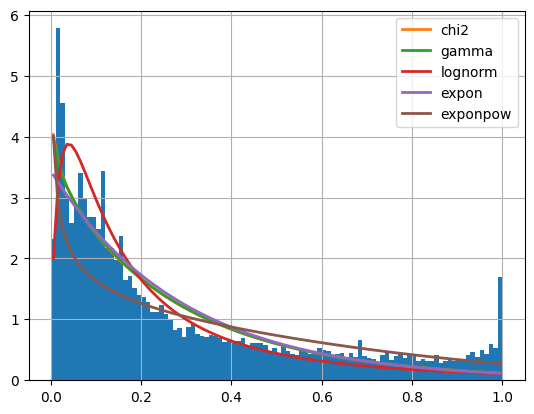

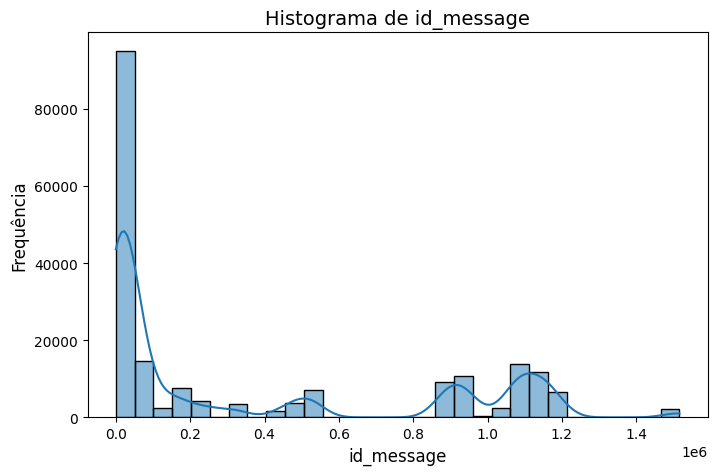


4. Boxplot:


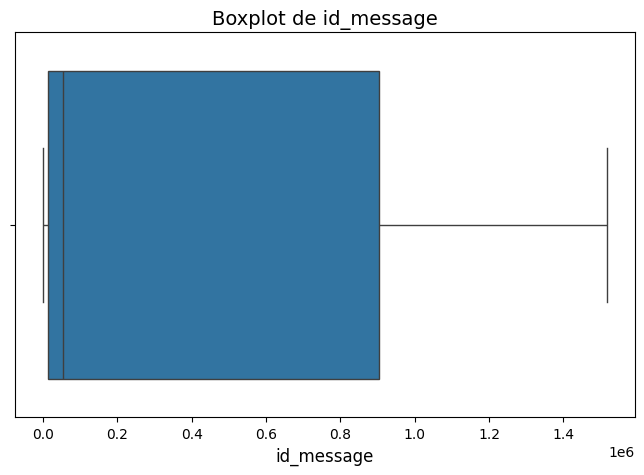


5. QQ-Plot (Gráfico de Probabilidade Normal):


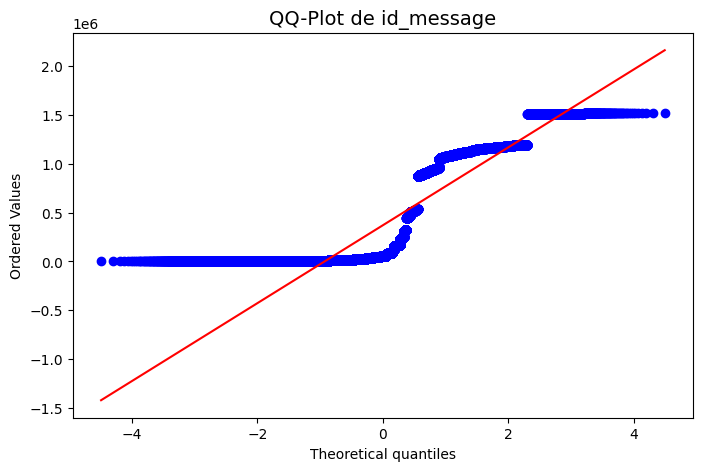


6. Teste de Normalidade (Shapiro-Wilk):
   - Estatística do teste = 0.740
   - p-valor = 0.000
   - Conclusão: A hipótese de normalidade é rejeitada (p <= 0.05).

7. Verificação da Melhor Distribuição de Ajuste:


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 197104.
  res = hypotest_fun_out(*samples, **kwds)


          sumsquare_error          aic          bic  kl_div  ks_statistic  \
lognorm      5.401444e-11  3097.778193  3128.352653     inf      0.154757   
exponpow     1.376350e-10  3008.436791  3039.011251     inf      0.164802   
powerlaw     1.574660e-10  2939.516069  2970.090530     inf      0.180429   
gamma        1.657371e-10  3257.556013  3288.130474     inf      0.281375   
cauchy       2.022961e-10  3342.699055  3363.082029     inf      0.349806   

          ks_pvalue  
lognorm         0.0  
exponpow        0.0  
powerlaw        0.0  
gamma           0.0  
cauchy          0.0  





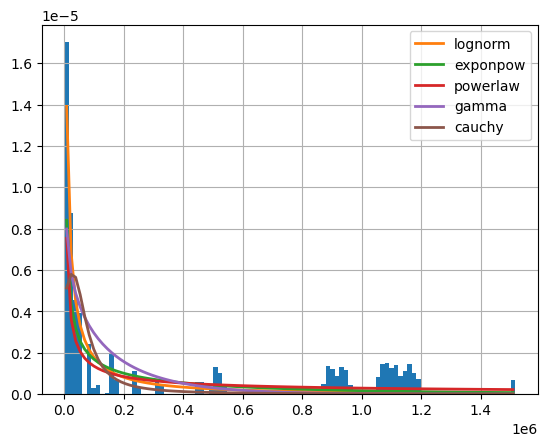

In [29]:
# Célula 6: Análise dos Atributos Numéricos

!pip install -q fitter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from fitter import Fitter, get_common_distributions

# Identificando colunas numéricas
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Colunas numéricas identificadas: {numeric_cols}\n")

for col in numeric_cols:
    print(f"==================================================")
    print(f" ANÁLISE DO ATRIBUTO: '{col}'")
    print(f"==================================================")

    data = df[col].dropna()

    # 1. Medidas de Tendência Central
    print("\n1. Medidas de Tendência Central:")
    print(f"   - Média: {data.mean():.2f}")
    print(f"   - Mediana: {data.median():.2f}")
    print(f"   - Moda: {data.mode().iloc[0] if not data.mode().empty else 'N/A'}")

    # 2. Medidas de Variabilidade
    print("\n2. Medidas de Variabilidade:")
    print(f"   - Variância: {data.var():.2f}")
    print(f"   - Desvio Padrão: {data.std():.2f}")
    print(f"   - Amplitude (Range): {data.max() - data.min():.2f}")

    # 3. Histograma
    print("\n3. Histograma:")
    plt.figure(figsize=(8, 5))
    sns.histplot(data, kde=True, bins=30)
    plt.title(f'Histograma de {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequência', fontsize=12)
    plt.show()

    # 4. Boxplot
    print("\n4. Boxplot:")
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=data)
    plt.title(f'Boxplot de {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.show()

    # 5. QQ-Plot
    print("\n5. QQ-Plot (Gráfico de Probabilidade Normal):")
    plt.figure(figsize=(8, 5))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'QQ-Plot de {col}', fontsize=14)
    plt.show()

    # 6. Teste de Normalidade (Shapiro-Wilk)
    print("\n6. Teste de Normalidade (Shapiro-Wilk):")
    if len(data) > 3:
        stat, p_value = stats.shapiro(data)
        print(f'   - Estatística do teste = {stat:.3f}')
        print(f'   - p-valor = {p_value:.3f}')
        if p_value > 0.05:
            print('   - Conclusão: Não há evidências para rejeitar a hipótese de normalidade (p > 0.05).')
        else:
            print('   - Conclusão: A hipótese de normalidade é rejeitada (p <= 0.05).')
    else:
        print('   - Não foi possível realizar o teste (menos de 4 amostras).')


    # 7. Best Fit Distribution
    print("\n7. Verificação da Melhor Distribuição de Ajuste:")
    f = Fitter(data, distributions=get_common_distributions())
    f.fit()
    print(f.summary())
    print("\n\n")

 ANÁLISE DE CORRELAÇÃO ENTRE PARES NUMÉRICOS

--- Analisando o par: 'dataset_info_id' e 'score_sentiment' ---
1. Coeficiente de Correlação de Pearson: nan
2. Gráfico de Dispersão:


/tmp/ipython-input-3681509775.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = stats.pearsonr(temp_df[col1], temp_df[col2])


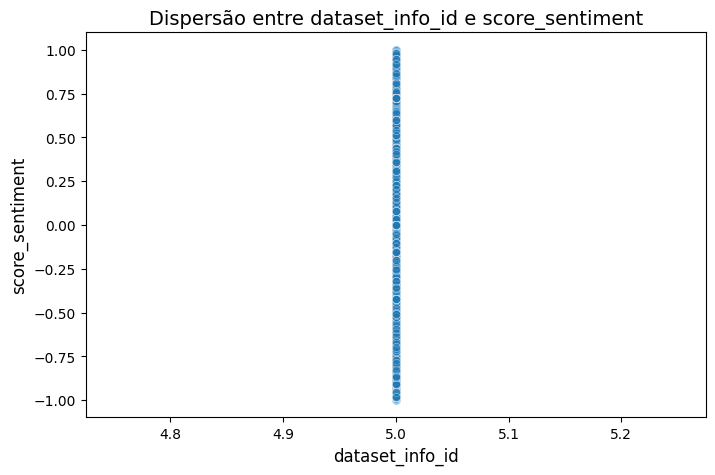


--- Analisando o par: 'dataset_info_id' e 'score_misinformation' ---
1. Coeficiente de Correlação de Pearson: nan
2. Gráfico de Dispersão:


/tmp/ipython-input-3681509775.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = stats.pearsonr(temp_df[col1], temp_df[col2])


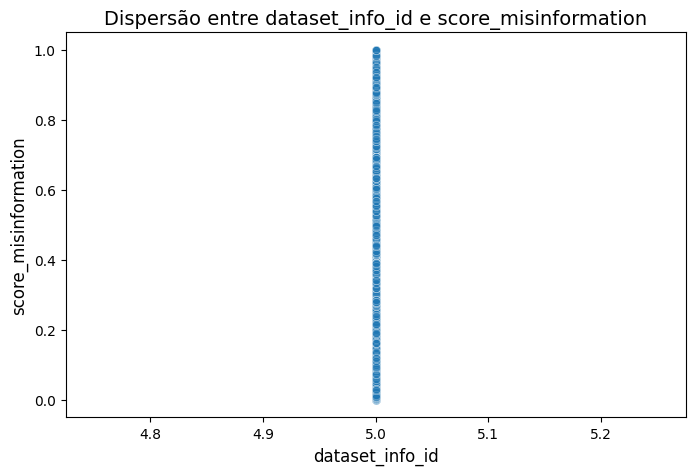


--- Analisando o par: 'dataset_info_id' e 'id_message' ---
1. Coeficiente de Correlação de Pearson: nan
2. Gráfico de Dispersão:


/tmp/ipython-input-3681509775.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = stats.pearsonr(temp_df[col1], temp_df[col2])


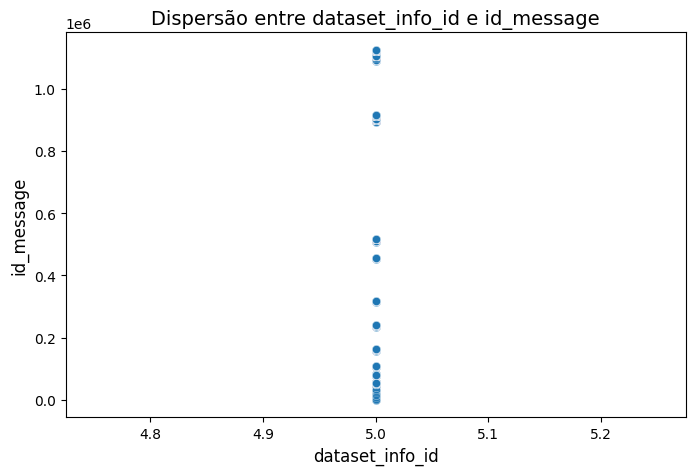


--- Analisando o par: 'score_sentiment' e 'score_misinformation' ---
1. Coeficiente de Correlação de Pearson: -0.357
2. Gráfico de Dispersão:


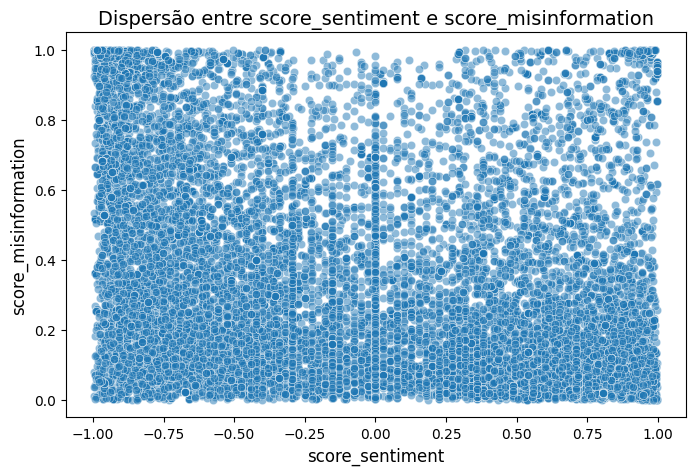


--- Analisando o par: 'score_sentiment' e 'id_message' ---
1. Coeficiente de Correlação de Pearson: -0.098
2. Gráfico de Dispersão:


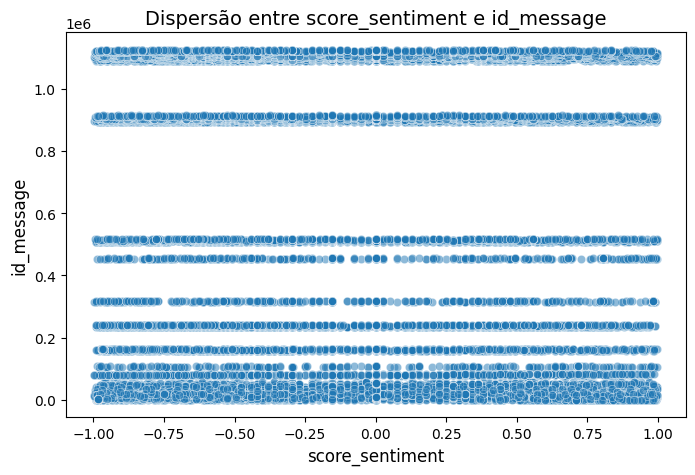


--- Analisando o par: 'score_misinformation' e 'id_message' ---
1. Coeficiente de Correlação de Pearson: 0.130
2. Gráfico de Dispersão:


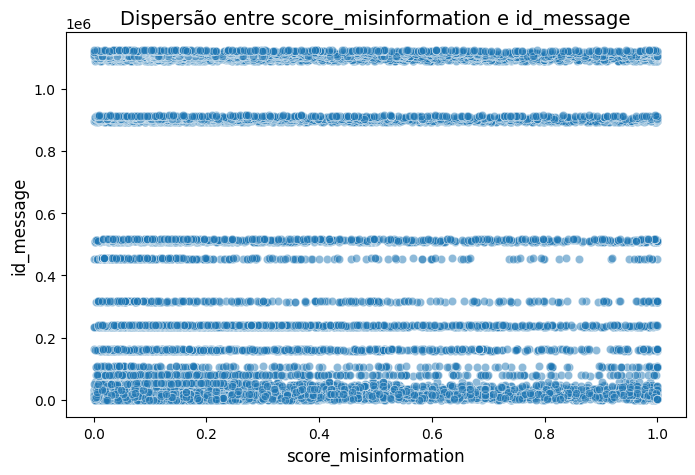

In [18]:
# Célula 7: Análise de Pares de Atributos Numéricos

print("==================================================")
print(" ANÁLISE DE CORRELAÇÃO ENTRE PARES NUMÉRICOS")
print("==================================================")

if len(numeric_cols) >= 2:
    for col1, col2 in combinations(numeric_cols, 2):
        print(f"\n--- Analisando o par: '{col1}' e '{col2}' ---")
        temp_df = df[[col1, col2]].dropna()

        # 1. Coeficiente de Correlação de Pearson
        correlation, _ = stats.pearsonr(temp_df[col1], temp_df[col2])
        print(f"1. Coeficiente de Correlação de Pearson: {correlation:.3f}")

        # 2. Gráfico de Dispersão
        print("2. Gráfico de Dispersão:")
        plt.figure(figsize=(8, 5))
        sns.scatterplot(x=col1, y=col2, data=temp_df, alpha=0.5)
        plt.title(f'Dispersão entre {col1} e {col2}', fontsize=14)
        plt.xlabel(col1, fontsize=12)
        plt.ylabel(col2, fontsize=12)
        plt.show()
else:
    print("Não há pares de atributos numéricos suficientes para análise.")

In [30]:
# Célula 8: Análise de Pares de Atributos Categóricos (V de Cramer)

from scipy.stats import chi2_contingency
from itertools import combinations
import numpy as np # Adicionado para corrigir o NameError

# Função para calcular o V de Cramer (sem alterações)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    if min(k-1, r-1) == 0:
        return 0
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min(kcorr-1, rcorr-1) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# --- CORREÇÃO PRINCIPAL: SELECIONAR APENAS COLUNAS RELEVANTES ---

# 1. Identifica todas as colunas de tipo 'object' ou 'category'
all_categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Define uma lista de colunas a serem EXCLUÍDAS da análise por terem muitas categorias únicas
cols_to_exclude = [
    'text_content_anonymous', # Texto da mensagem
    'date_message',           # Data/hora exata
    'id_member_anonymous',    # ID de usuário
    'id_group_anonymous',     # ID de grupo
    'media_url',              # URLs de mídia
    'media_name',             # Nomes de arquivos de mídia
    'media_md5',              # Hash MD5
    'date_system'             # Data/hora do sistema
]

# 3. Cria a lista final de colunas para a análise, removendo as excluídas
cols_for_cramer = [col for col in all_categorical_cols if col not in cols_to_exclude]

print("==================================================")
print(" ANÁLISE DE ASSOCIAÇÃO ENTRE PARES CATEGÓRICOS")
print("==================================================")
print(f"Colunas Categóricas selecionadas para a análise: {cols_for_cramer}\n")

# 4. Executa o loop apenas com a lista filtrada de colunas
if len(cols_for_cramer) >= 2:
    for col1, col2 in combinations(cols_for_cramer, 2):
        # Adicionado um 'try-except' para segurança extra
        try:
            v_cramer = cramers_v(df[col1], df[col2])
            print(f"V de Cramer entre '{col1}' e '{col2}': {v_cramer:.3f}")
        except Exception as e:
            print(f"Não foi possível calcular o V de Cramer para '{col1}' e '{col2}'. Erro: {e}")
else:
    print("Não há pares de atributos categóricos suficientes para análise.")

 ANÁLISE DE ASSOCIAÇÃO ENTRE PARES CATEGÓRICOS
Colunas Categóricas selecionadas para a análise: ['media', 'media_type', 'has_media', 'has_media_url', 'trava_zap', 'message_type', 'messenger']

V de Cramer entre 'media' e 'media_type': 0.675
V de Cramer entre 'media' e 'has_media': 0.000
V de Cramer entre 'media' e 'has_media_url': 0.720
V de Cramer entre 'media' e 'trava_zap': 0.000
V de Cramer entre 'media' e 'message_type': 0.727
V de Cramer entre 'media' e 'messenger': 0.000
V de Cramer entre 'media_type' e 'has_media': 0.000
V de Cramer entre 'media_type' e 'has_media_url': 0.676
V de Cramer entre 'media_type' e 'trava_zap': 0.000
V de Cramer entre 'media_type' e 'message_type': 1.000
V de Cramer entre 'media_type' e 'messenger': 0.000
V de Cramer entre 'has_media' e 'has_media_url': 0.455
V de Cramer entre 'has_media' e 'trava_zap': 0.000
V de Cramer entre 'has_media' e 'message_type': 1.000
V de Cramer entre 'has_media' e 'messenger': 0.000
V de Cramer entre 'has_media_url' e 'tr

In [32]:
# Célula de Preparação

# --- Instalações ---
!pip install wordcloud
!pip install pyvis
!pip install nltk

# --- Importações ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from urllib.parse import urlparse
from collections import Counter
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import networkx as nx
from pyvis.network import Network

# --- Configurações ---
# Baixar recursos do NLTK (necessário apenas na primeira vez)
try:
    stopwords.words('portuguese')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')

# Definir a paleta de cores padrão para os gráficos
sns.set_palette("viridis")
sns.set_style("whitegrid")

# --- Pré-processamento do DataFrame 'df' ---
# Garantir que as colunas de data sejam do tipo datetime
df['date_message'] = pd.to_datetime(df['date_message'])

# Criar uma coluna com a contagem de palavras para cada mensagem
df['word_count'] = df['text_content_anonymous'].astype(str).str.split().str.len()

# Função para extrair URLs
def extract_urls(text):
    if isinstance(text, str):
        return re.findall(r'(https?://\S+)', text)
    return []

# Função segura para obter o netloc (domínio) de uma URL
def safe_get_netloc(url):
    try:
        # urlparse pode levantar ValueError para URLs com hostnames entre colchetes inválidos (e.g., http://[EMAIL])
        parsed_url = urlparse(url)
        # Retorna o netloc apenas se não estiver vazio
        if parsed_url.netloc:
            return parsed_url.netloc
    except ValueError:
        # Ignora URLs que causam erro de validação interna (como o '[EMAIL]' do traceback)
        pass
    return None

# Criar coluna com URLs e domínios
df['urls'] = df['text_content_anonymous'].apply(extract_urls)
# Usar a função safe_get_netloc para evitar erros ao extrair domínios
df['domains'] = df['urls'].apply(lambda urls_list: [
    domain for url in urls_list if (domain := safe_get_netloc(url)) is not None
])

print("Preparação concluída. O DataFrame 'df' foi enriquecido com novas colunas.")

Preparação concluída. O DataFrame 'df' foi enriquecido com novas colunas.


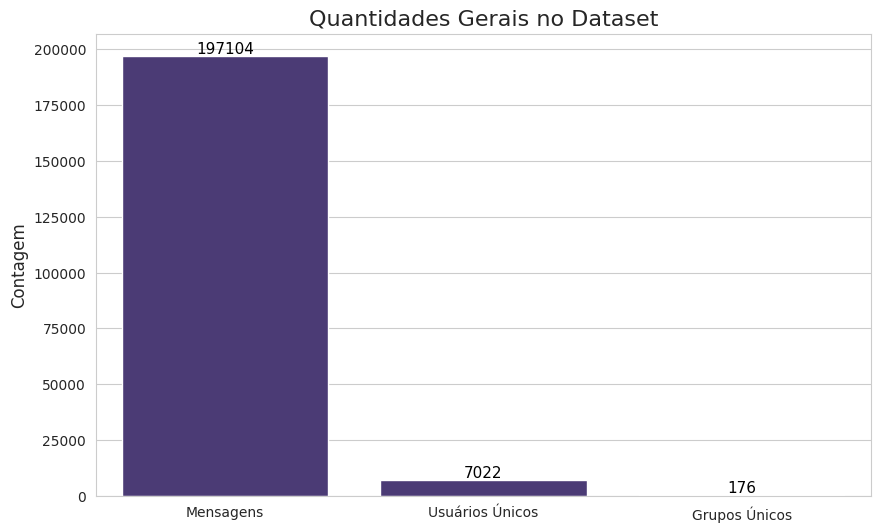

In [33]:
# Célula 1: Gráfico de Quantidades Gerais

# Contagem de valores únicos
total_messages = len(df)
total_users = df['id_member_anonymous'].nunique()
total_groups = df['id_group_anonymous'].nunique()

# Criando o DataFrame para o gráfico
data = {
    'Entidade': ['Mensagens', 'Usuários Únicos', 'Grupos Únicos'],
    'Quantidade': [total_messages, total_users, total_groups]
}
summary_df = pd.DataFrame(data)

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Entidade', y='Quantidade', data=summary_df)
ax.set_title('Quantidades Gerais no Dataset', fontsize=16)
ax.set_ylabel('Contagem', fontsize=12)
ax.set_xlabel('')

# Adicionando os valores no topo das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

/tmp/ipython-input-3869234404.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Apenas Texto', 'Contém Mídia'])


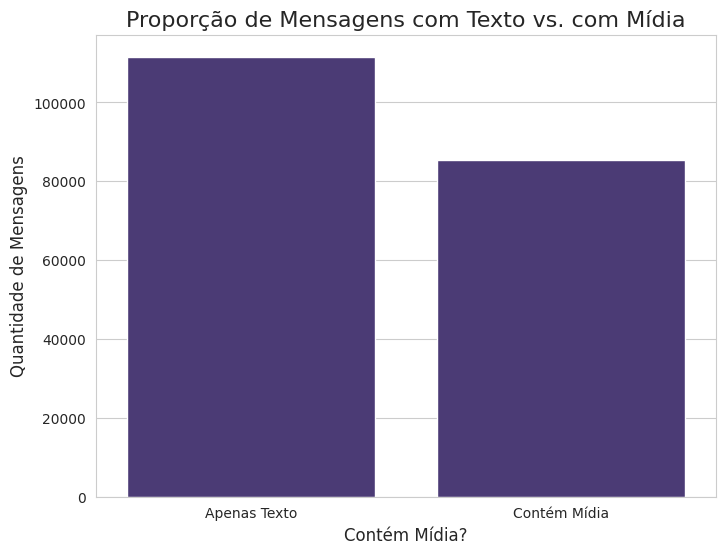

In [34]:
# Célula 2: Texto vs. Mídia

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='has_media', data=df)
ax.set_title('Proporção de Mensagens com Texto vs. com Mídia', fontsize=16)
ax.set_xlabel('Contém Mídia?', fontsize=12)
ax.set_ylabel('Quantidade de Mensagens', fontsize=12)
ax.set_xticklabels(['Apenas Texto', 'Contém Mídia'])
plt.show()

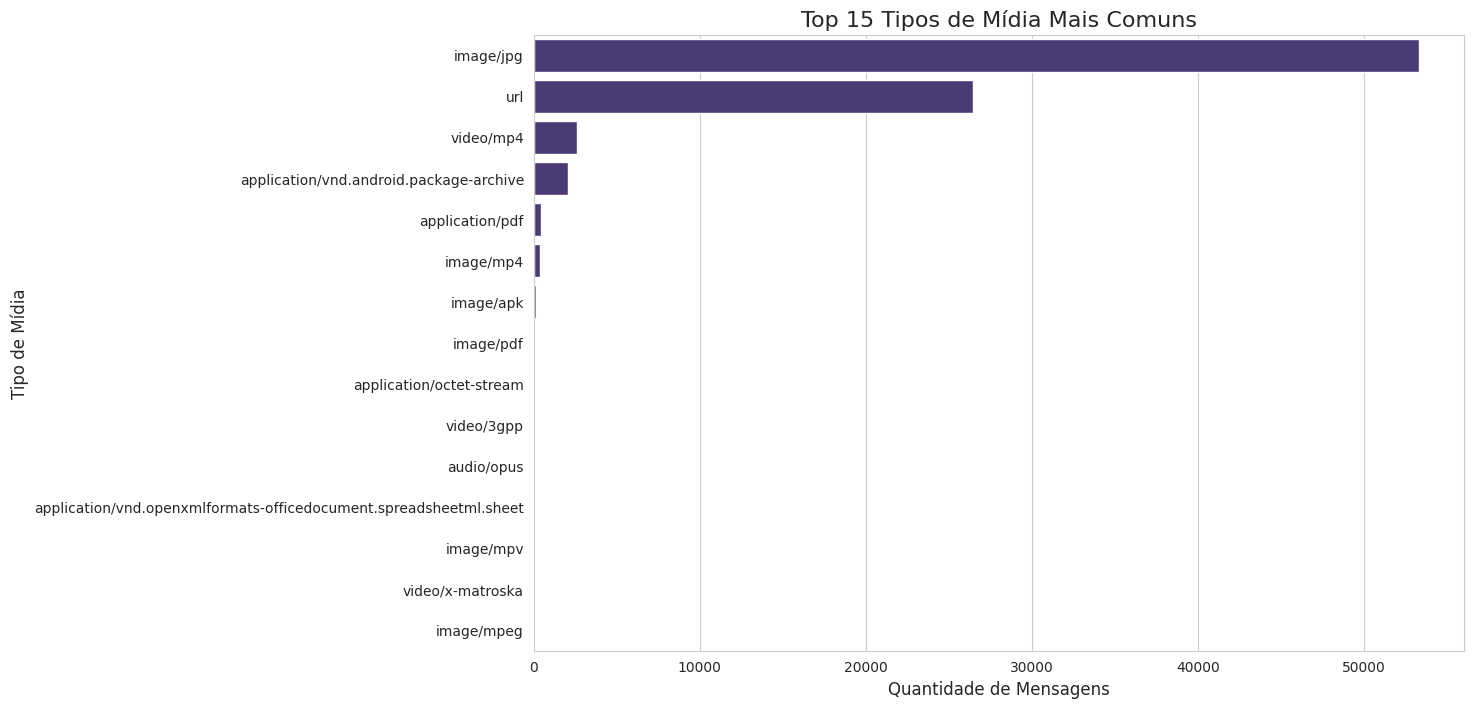

In [35]:
# Célula 3: Quantidade por Tipo de Mídia

# Filtrar apenas mensagens com mídia e contar os tipos
media_types = df[df['has_media'] == True]['media_type'].value_counts().nlargest(15)

plt.figure(figsize=(12, 8))
ax = sns.barplot(y=media_types.index, x=media_types.values, orient='h')
ax.set_title('Top 15 Tipos de Mídia Mais Comuns', fontsize=16)
ax.set_xlabel('Quantidade de Mensagens', fontsize=12)
ax.set_ylabel('Tipo de Mídia', fontsize=12)
plt.show()

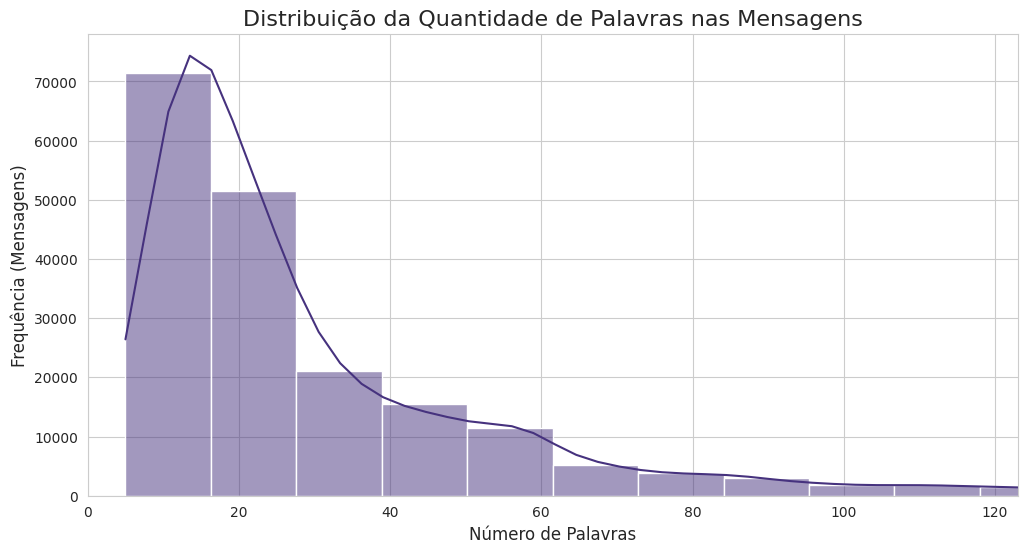

In [36]:
# Célula 4: Distribuição da Quantidade de Palavras por Mensagem

plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Distribuição da Quantidade de Palavras nas Mensagens', fontsize=16)
plt.xlabel('Número de Palavras', fontsize=12)
plt.ylabel('Frequência (Mensagens)', fontsize=12)
plt.xlim(0, df['word_count'].quantile(0.95)) # Limita o eixo X para melhor visualização
plt.show()

In [39]:
# Célula 5, 6 e 7: Análise por Estado

print("AVISO: O dataset atual não possui uma coluna com a localização geográfica (Estado/País) dos usuários ou mensagens.")
print("Portanto, não é possível gerar as visualizações de 5 a 9.")
print("Para realizar essa análise, seria necessário enriquecer o dataset com dados de geolocalização.")

# Célula 8 e 9: Análise por País

print("AVISO: Conforme mencionado anteriormente, o dataset não contém dados de localização (país).")
print("As análises 8 e 9 não podem ser executadas com os dados atuais.")

AVISO: O dataset atual não possui uma coluna com a localização geográfica (Estado/País) dos usuários ou mensagens.
Portanto, não é possível gerar as visualizações de 5 a 9.
Para realizar essa análise, seria necessário enriquecer o dataset com dados de geolocalização.
AVISO: Conforme mencionado anteriormente, o dataset não contém dados de localização (país).
As análises 8 e 9 não podem ser executadas com os dados atuais.


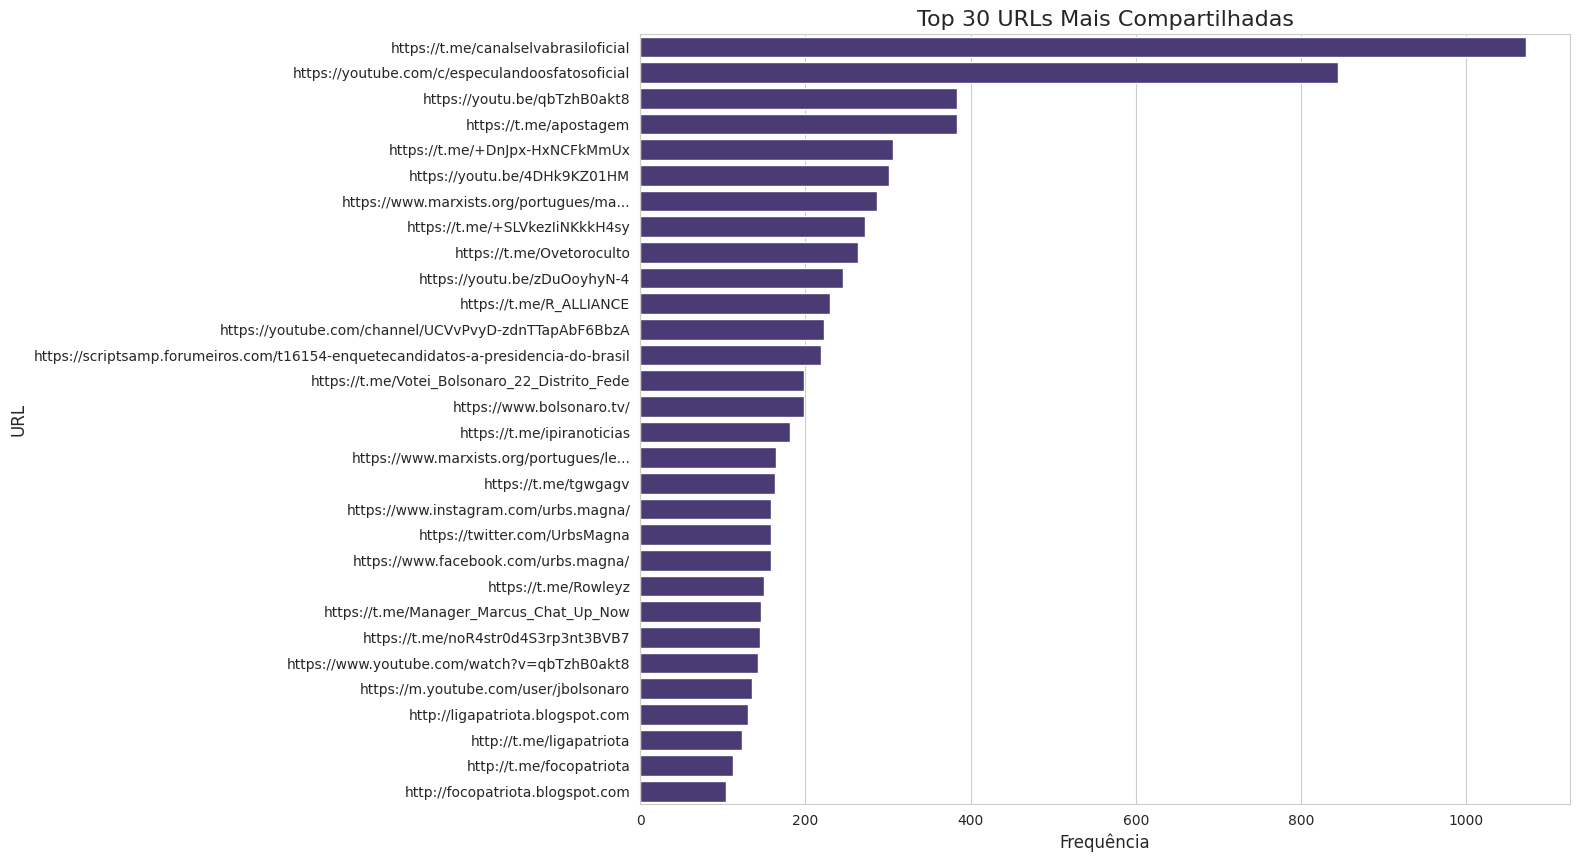

In [40]:
# Célula 10: Top 30 URLs

# 'Explode' a lista de URLs em linhas separadas e conta as ocorrências
top_urls = df.explode('urls').dropna(subset=['urls'])['urls'].value_counts().nlargest(30)

plt.figure(figsize=(12, 10))
ax = sns.barplot(y=top_urls.index, x=top_urls.values, orient='h')
ax.set_title('Top 30 URLs Mais Compartilhadas', fontsize=16)
ax.set_xlabel('Frequência', fontsize=12)
ax.set_ylabel('URL', fontsize=12)
plt.show()

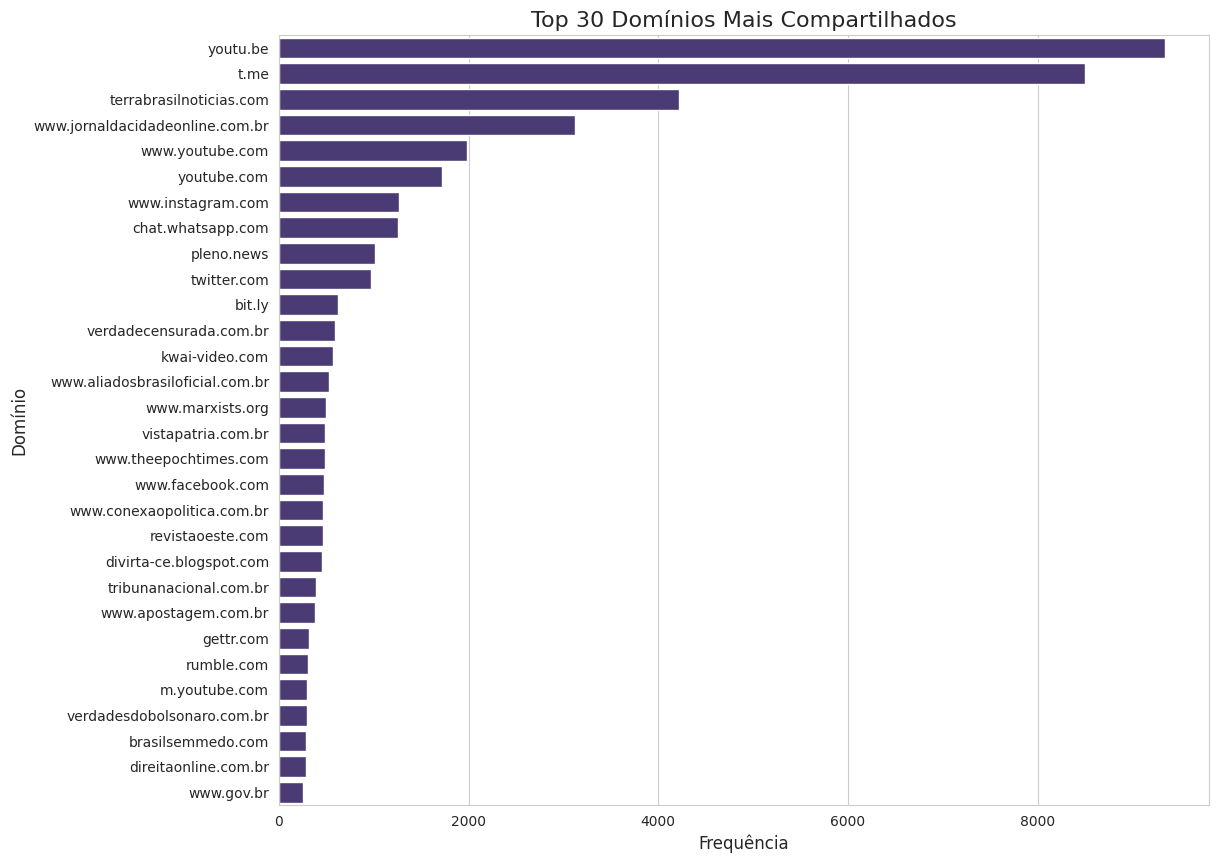

In [41]:
# Célula 11: Top 30 Domínios

# 'Explode' a lista de domínios e conta as ocorrências
top_domains = df.explode('domains').dropna(subset=['domains'])['domains'].value_counts().nlargest(30)

plt.figure(figsize=(12, 10))
ax = sns.barplot(y=top_domains.index, x=top_domains.values, orient='h')
ax.set_title('Top 30 Domínios Mais Compartilhados', fontsize=16)
ax.set_xlabel('Frequência', fontsize=12)
ax.set_ylabel('Domínio', fontsize=12)
plt.show()

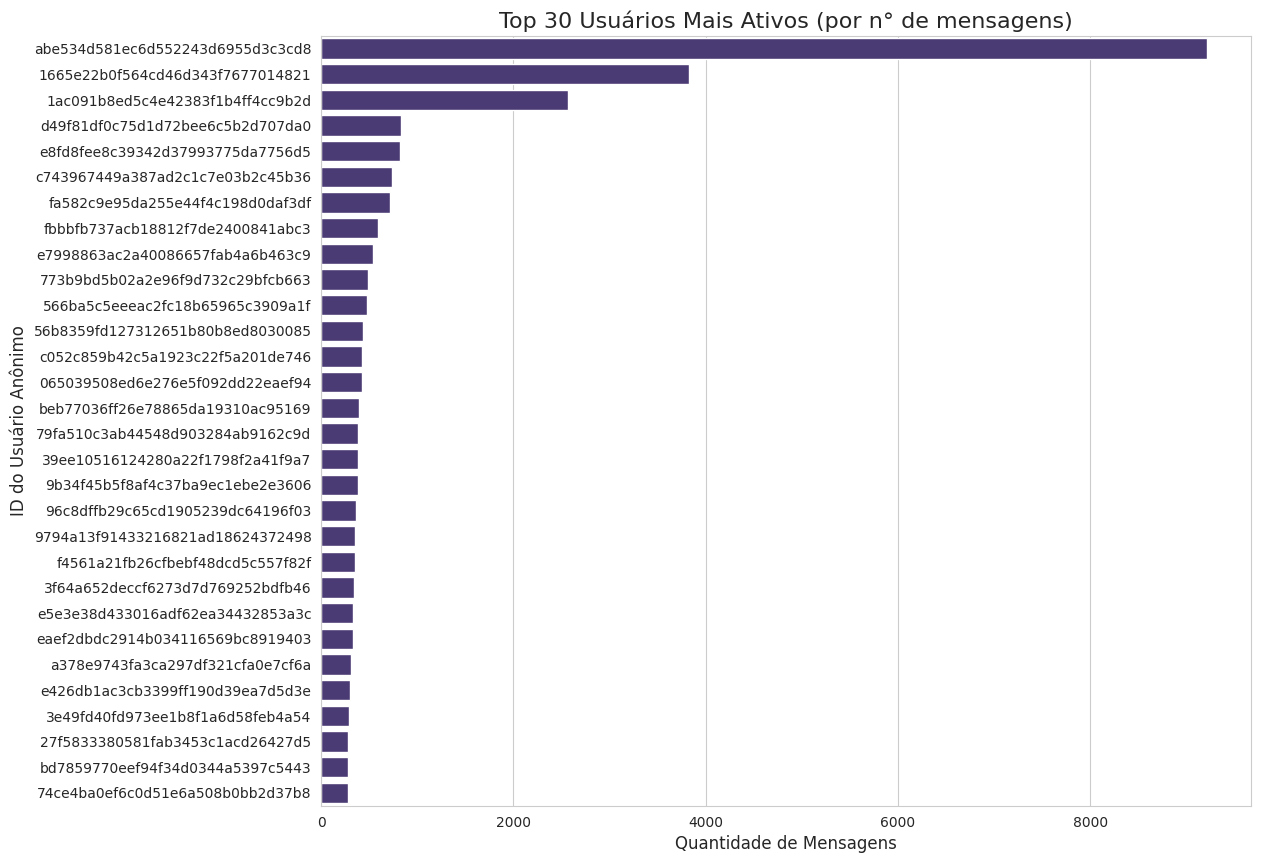

In [42]:
# Célula 12: Top 30 Usuários Ativos

top_users = df['id_member_anonymous'].value_counts().nlargest(30)

plt.figure(figsize=(12, 10))
ax = sns.barplot(y=top_users.index.astype(str), x=top_users.values, orient='h')
ax.set_title('Top 30 Usuários Mais Ativos (por n° de mensagens)', fontsize=16)
ax.set_xlabel('Quantidade de Mensagens', fontsize=12)
ax.set_ylabel('ID do Usuário Anônimo', fontsize=12)
plt.show()

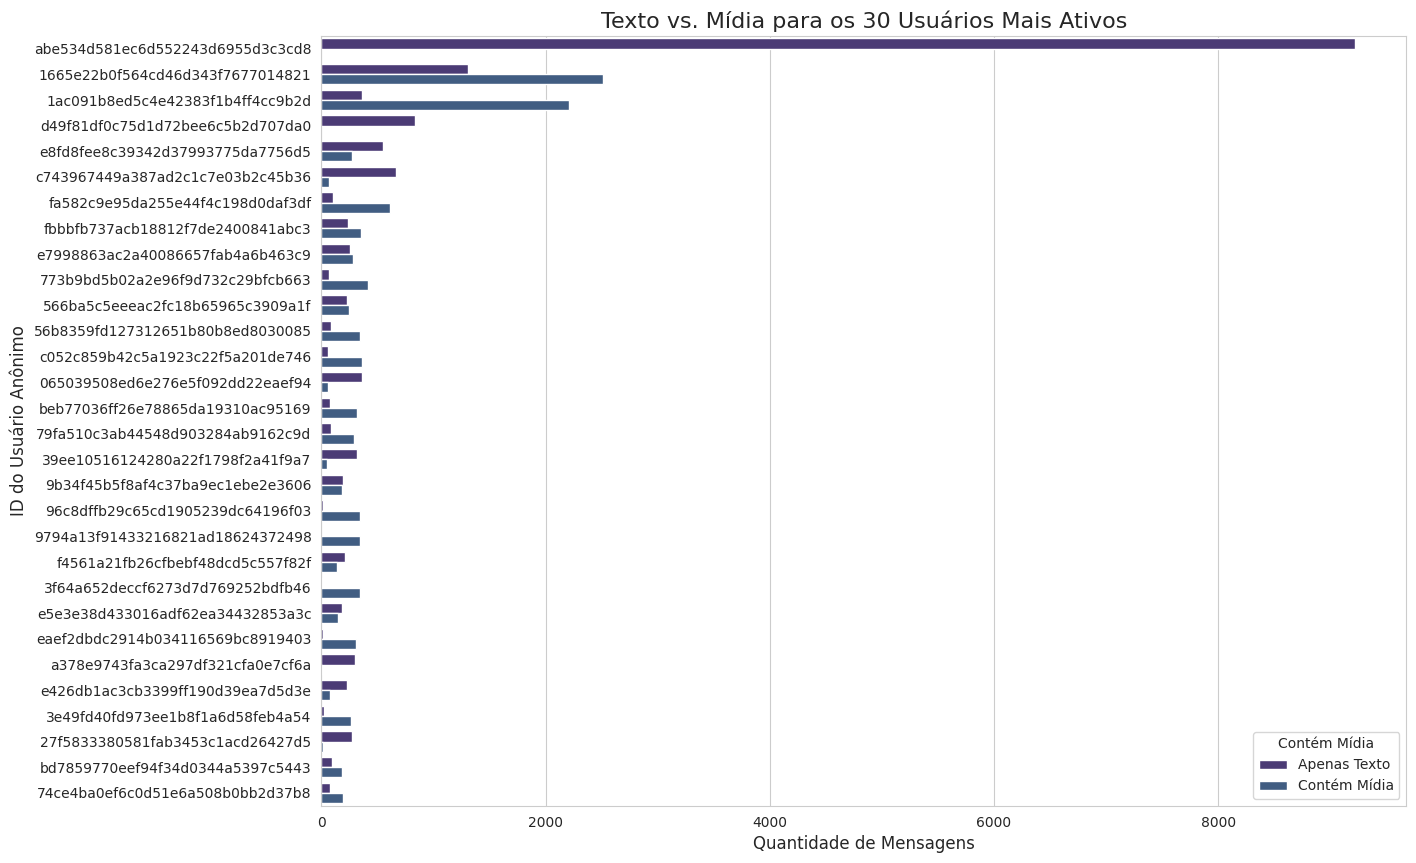

In [43]:
# Célula 13: Texto vs. Mídia dos Usuários Mais Ativos

# Pega a lista dos IDs dos top usuários
top_users_ids = top_users.index

# Filtra o DF original para conter apenas esses usuários
df_top_users = df[df['id_member_anonymous'].isin(top_users_ids)]

plt.figure(figsize=(14, 10))
sns.countplot(y='id_member_anonymous', hue='has_media', data=df_top_users, order=top_users_ids, orient='h')
plt.title('Texto vs. Mídia para os 30 Usuários Mais Ativos', fontsize=16)
plt.xlabel('Quantidade de Mensagens', fontsize=12)
plt.ylabel('ID do Usuário Anônimo', fontsize=12)
plt.legend(title='Contém Mídia', labels=['Apenas Texto', 'Contém Mídia'])
plt.show()

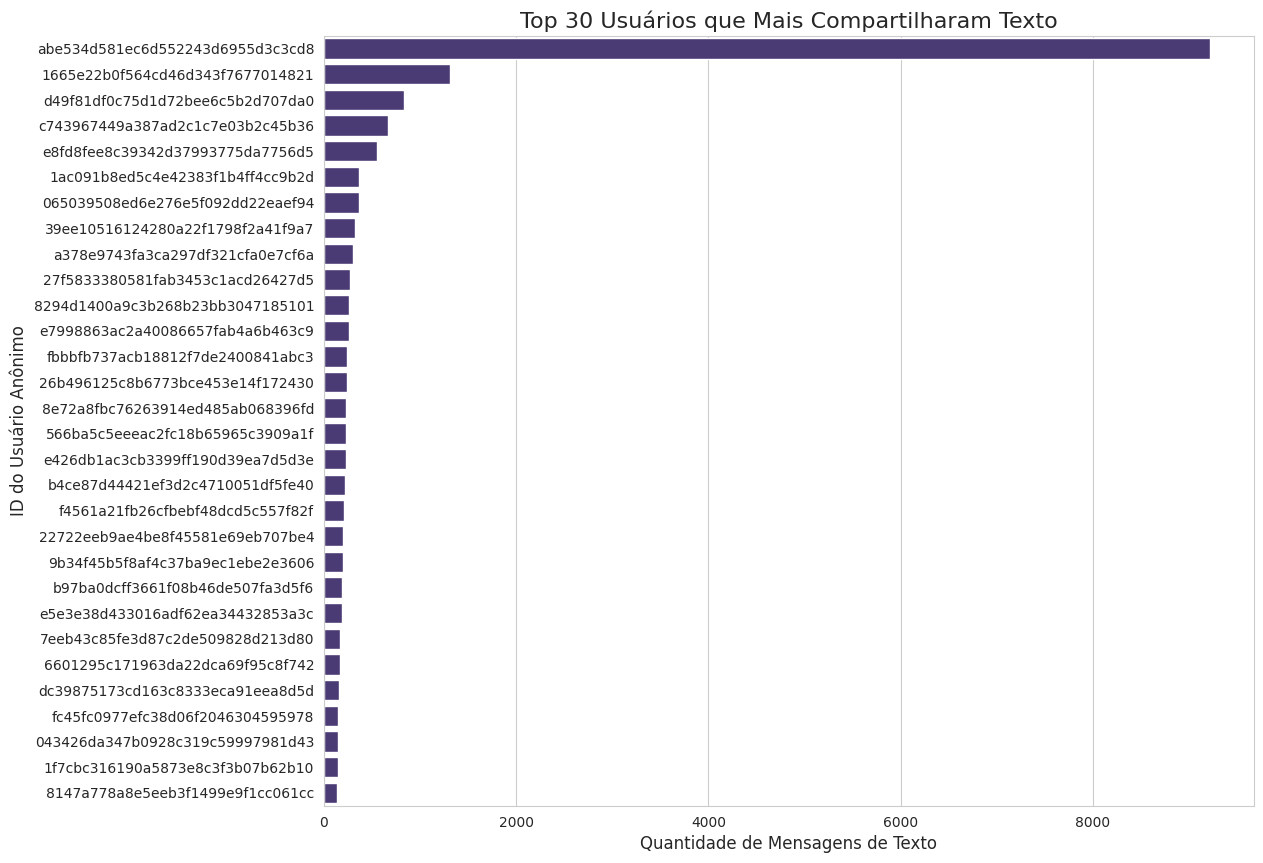

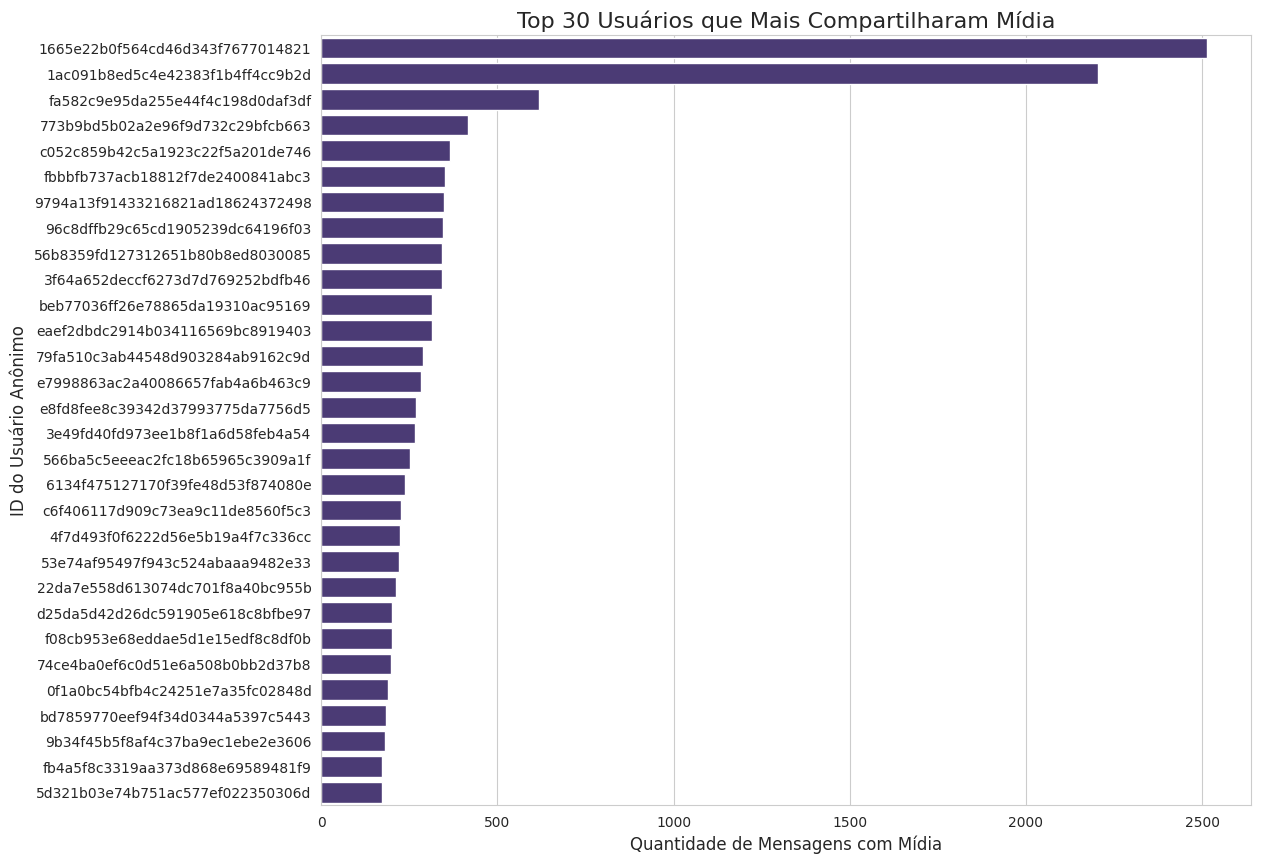

In [47]:
# Célula 14: Top 30 Compartilhadores de Texto

top_text_users = df[df['has_media'] == False]['id_member_anonymous'].value_counts().nlargest(30)

plt.figure(figsize=(12, 10))
ax = sns.barplot(y=top_text_users.index.astype(str), x=top_text_users.values, orient='h')
ax.set_title('Top 30 Usuários que Mais Compartilharam Texto', fontsize=16)
ax.set_xlabel('Quantidade de Mensagens de Texto', fontsize=12)
ax.set_ylabel('ID do Usuário Anônimo', fontsize=12)
plt.show()

# Célula 15: Top 30 Compartilhadores de Mídia

top_media_users = df[df['has_media'] == True]['id_member_anonymous'].value_counts().nlargest(30)

plt.figure(figsize=(12, 10))
ax = sns.barplot(y=top_media_users.index.astype(str), x=top_media_users.values, orient='h')
ax.set_title('Top 30 Usuários que Mais Compartilharam Mídia', fontsize=16)
ax.set_xlabel('Quantidade de Mensagens com Mídia', fontsize=12)
ax.set_ylabel('ID do Usuário Anônimo', fontsize=12)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128584 (\N{SEE-NO-EVIL MONKEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127479 (\N{REGIONAL INDICATOR SYMBOL LETTER R}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font

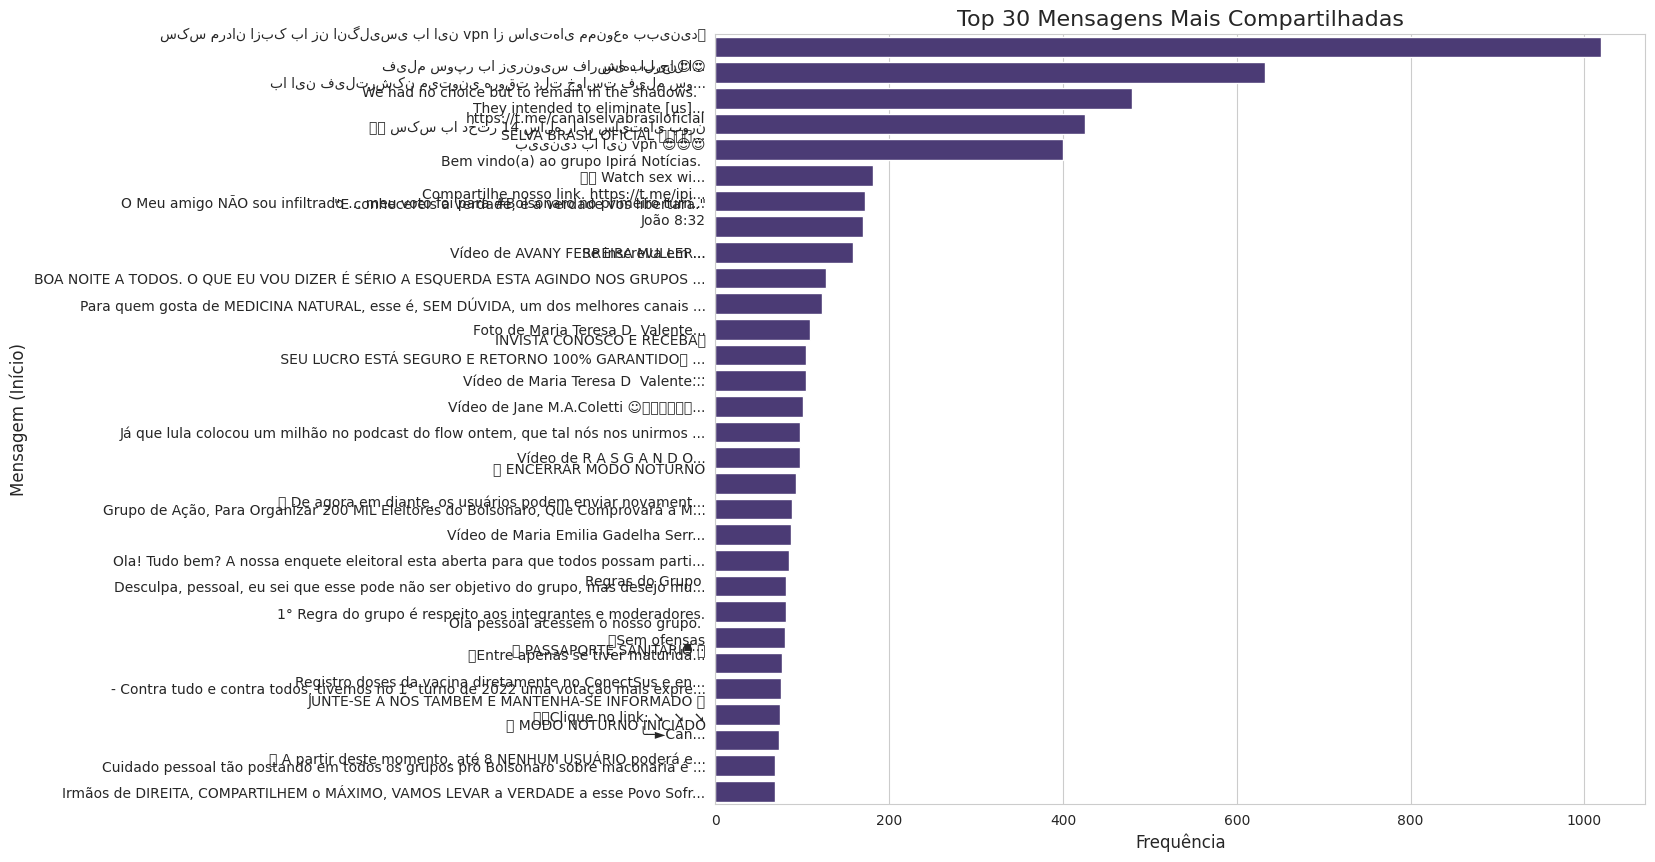

In [49]:
# Célula 16: As 30 Mensagens Mais Compartilhadas

top_messages = df['text_content_anonymous'].value_counts().nlargest(30)

plt.figure(figsize=(12, 10))
ax = sns.barplot(y=top_messages.index.str[:80] + '...', x=top_messages.values, orient='h') # Trunca o texto
ax.set_title('Top 30 Mensagens Mais Compartilhadas', fontsize=16)
ax.set_xlabel('Frequência', fontsize=12)
ax.set_ylabel('Mensagem (Início)', fontsize=12)
plt.show()

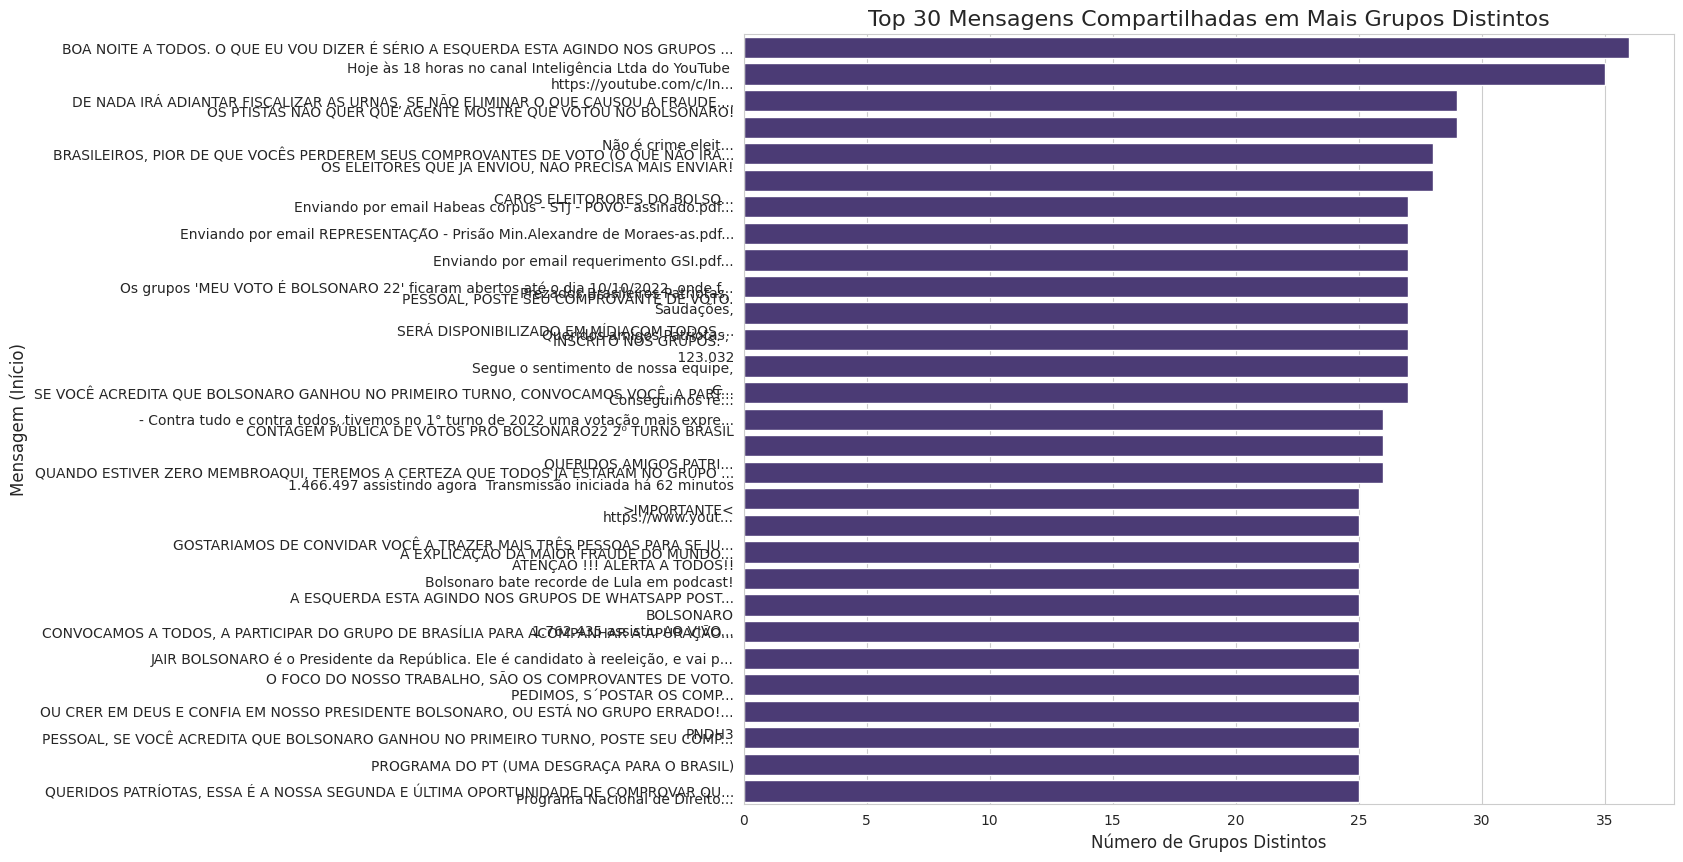

In [50]:
# Célula 17: Mensagens Mais Virais Entre Grupos

# Agrupa por mensagem e conta o número de grupos únicos
viral_messages = df.groupby('text_content_anonymous')['id_group_anonymous'].nunique().nlargest(30)

plt.figure(figsize=(12, 10))
ax = sns.barplot(y=viral_messages.index.str[:80] + '...', x=viral_messages.values, orient='h')
ax.set_title('Top 30 Mensagens Compartilhadas em Mais Grupos Distintos', fontsize=16)
ax.set_xlabel('Número de Grupos Distintos', fontsize=12)
ax.set_ylabel('Mensagem (Início)', fontsize=12)
plt.show()

In [51]:
# Célula 18 e 19: Mensagens Idênticas (Tabela)

# 18: Mensagens idênticas compartilhadas pelo mesmo usuário
same_user_messages = df.groupby(['id_member_anonymous', 'text_content_anonymous']).size().reset_index(name='count')
top_repeated_by_user = same_user_messages[same_user_messages['count'] > 1].sort_values('count', ascending=False).head(20)

print("--- Top 20: Mensagens Idênticas Compartilhadas pelo Mesmo Usuário ---")
print(top_repeated_by_user)
print("\n" + "="*80 + "\n")

# 19: Mensagens idênticas compartilhadas pelo mesmo usuário em grupos distintos
same_user_diff_group = df.groupby(['id_member_anonymous', 'text_content_anonymous'])['id_group_anonymous'].nunique().reset_index(name='unique_groups')
top_viral_by_user = same_user_diff_group[same_user_diff_group['unique_groups'] > 1].sort_values('unique_groups', ascending=False).head(20)

print("--- Top 20: Mensagens Idênticas Compartilhadas pelo Mesmo Usuário em Grupos Distintos ---")
print(top_viral_by_user)

--- Top 20: Mensagens Idênticas Compartilhadas pelo Mesmo Usuário ---
                    id_member_anonymous  \
4134   1665e22b0f564cd46d343f7677014821   
7153   17916aca7f2d50e4f30761dd76986ff6   
62124  f32fb55955515e8a98429f9089df960f   
20166  566ba5c5eeeac2fc18b65965c3909a1f   
7059   167db5613cd8235c443146d086ef40aa   
58703  e7998863ac2a40086657fab4a6b463c9   
58851  e7998863ac2a40086657fab4a6b463c9   
10828  23d14a50cb82952a04645e779f48206a   
22071  5f47c8d650969393e25000a927219611   
26423  773b9bd5b02a2e96f9d732c29bfcb663   
14670  396c035099bb75f47a1f08f59432f82c   
7049   1665e22b0f564cd46d343f7677014821   
55395  d94337b1b8b21dc0cf178886c93d890e   
51192  c743967449a387ad2c1c7e03b2c45b36   
32334  97ac116fb958a80ae81d54d3bb6ece2c   
50800  c6f406117d909c73ea9c11de8560f5c3   
2715   0dcbe3583c61d714db240e48abb186ec   
6820   1665e22b0f564cd46d343f7677014821   
35716  a8870bfe23ad4cfd5b3fedb5f26ccff5   
7050   1665e22b0f564cd46d343f7677014821   

                          

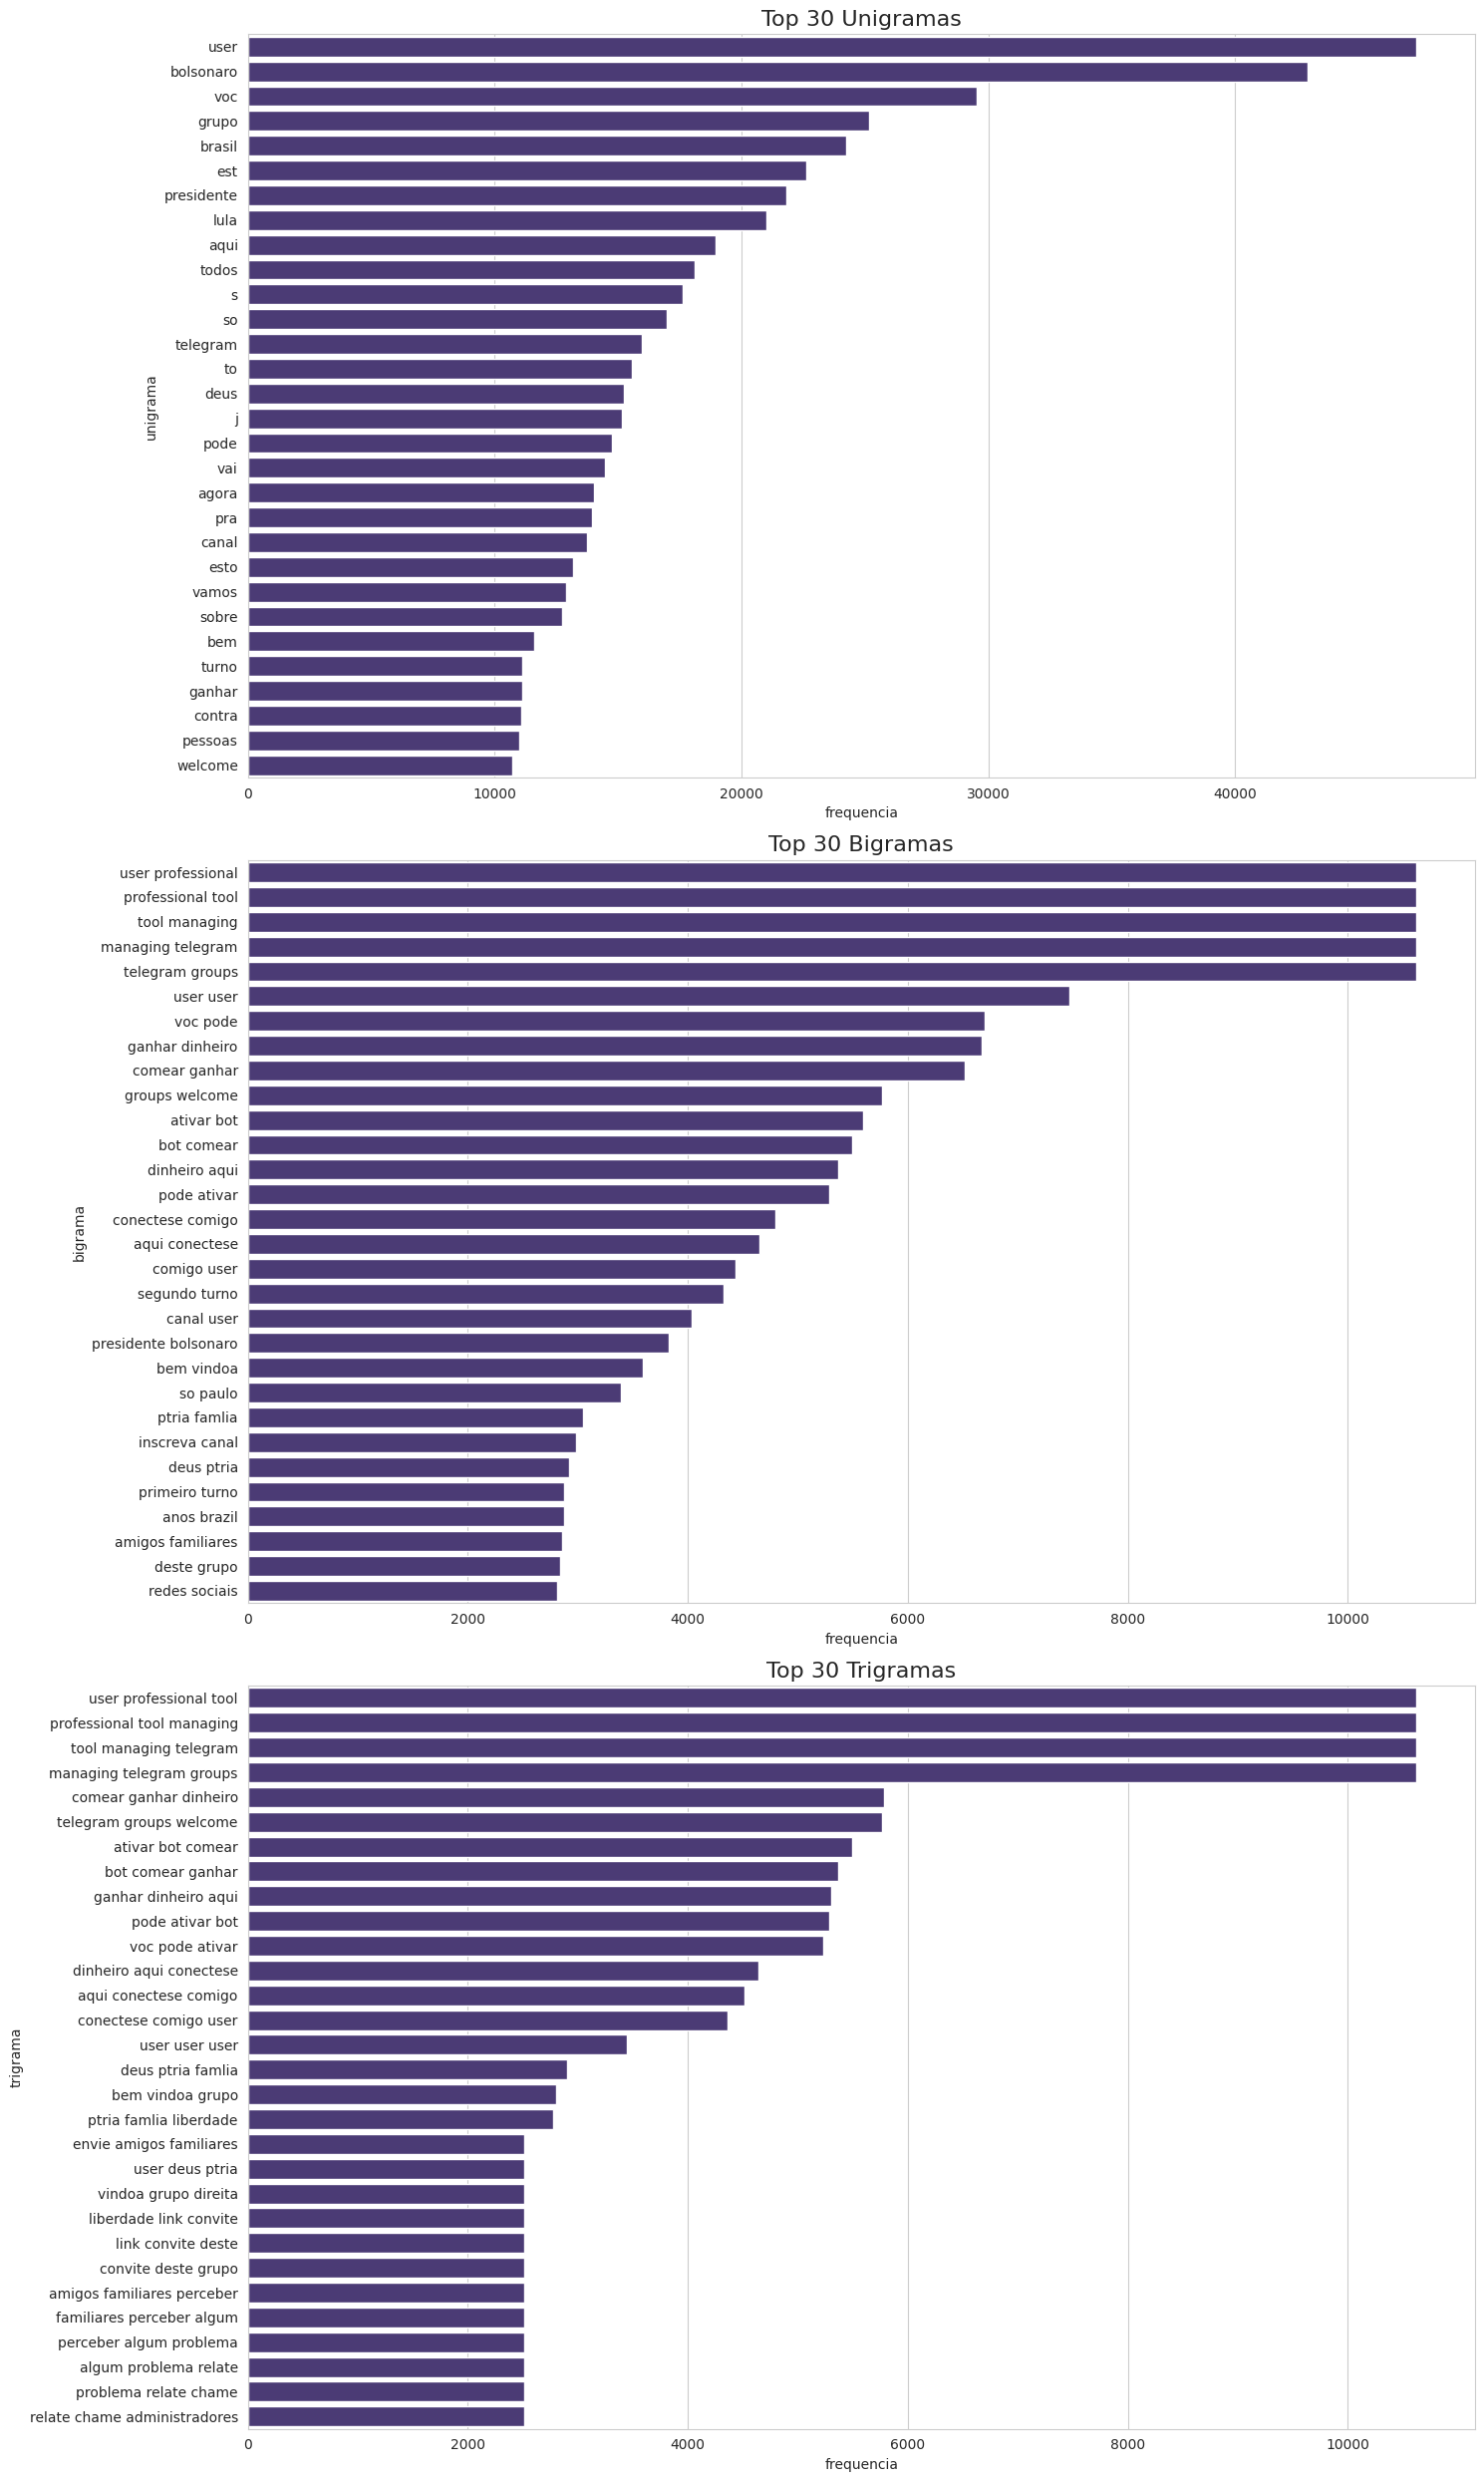

In [52]:
# Célula 20: N-gramas

# Preparação do texto
stop_words = set(stopwords.words('portuguese'))
corpus = df['text_content_anonymous'].str.lower().str.cat(sep=' ')
corpus = re.sub(r'[^a-zA-Z\s]', '', corpus)
words = [word for word in corpus.split() if word not in stop_words]

# Unigramas
unigrams = Counter(words).most_common(30)
unigram_df = pd.DataFrame(unigrams, columns=['unigrama', 'frequencia'])

# Bigramas
bigrams = Counter(nltk.bigrams(words)).most_common(30)
bigram_df = pd.DataFrame(bigrams, columns=['bigrama', 'frequencia'])
bigram_df['bigrama'] = bigram_df['bigrama'].apply(lambda x: ' '.join(x))

# Trigramas
trigrams = Counter(nltk.trigrams(words)).most_common(30)
trigram_df = pd.DataFrame(trigrams, columns=['trigrama', 'frequencia'])
trigram_df['trigrama'] = trigram_df['trigrama'].apply(lambda x: ' '.join(x))


# Gráficos
fig, axes = plt.subplots(3, 1, figsize=(15, 25))

sns.barplot(ax=axes[0], y='unigrama', x='frequencia', data=unigram_df, orient='h')
axes[0].set_title('Top 30 Unigramas', fontsize=16)

sns.barplot(ax=axes[1], y='bigrama', x='frequencia', data=bigram_df, orient='h')
axes[1].set_title('Top 30 Bigramas', fontsize=16)

sns.barplot(ax=axes[2], y='trigrama', x='frequencia', data=trigram_df, orient='h')
axes[2].set_title('Top 30 Trigramas', fontsize=16)

plt.tight_layout()
plt.show()

In [53]:
# Célula 21 a 26: Sentimentos e Tamanho (Tabelas)

pd.set_option('display.max_colwidth', 150)

# 21: Mensagens mais positivas
print("--- Top 30 Mensagens Mais Positivas ---")
print(df.drop_duplicates(subset=['text_content_anonymous']).sort_values('score_sentiment', ascending=False)[['text_content_anonymous', 'score_sentiment']].head(30))
print("\n" + "="*80 + "\n")

# 22: Mensagens mais negativas
print("--- Top 30 Mensagens Mais Negativas ---")
print(df.drop_duplicates(subset=['text_content_anonymous']).sort_values('score_sentiment', ascending=True)[['text_content_anonymous', 'score_sentiment']].head(30))
print("\n" + "="*80 + "\n")

# 23: Usuário mais otimista (maior score médio de sentimento)
optimistic_user = df.groupby('id_member_anonymous')['score_sentiment'].mean().idxmax()
print(f"--- Usuário Mais Otimista (maior score médio): {optimistic_user} ---")
print("\n" + "="*80 + "\n")

# 24: Usuário mais pessimista (menor score médio de sentimento)
pessimistic_user = df.groupby('id_member_anonymous')['score_sentiment'].mean().idxmin()
print(f"--- Usuário Mais Pessimista (menor score médio): {pessimistic_user} ---")
print("\n" + "="*80 + "\n")

# 25: 30 maiores mensagens
print("--- As 30 Maiores Mensagens (em n° de palavras) ---")
print(df.sort_values('word_count', ascending=False)[['text_content_anonymous', 'word_count']].head(30))
print("\n" + "="*80 + "\n")

# 26: 30 menores mensagens
print("--- As 30 Menores Mensagens (em n° de palavras, >= 5) ---")
print(df.sort_values('word_count', ascending=True)[['text_content_anonymous', 'word_count']].head(30))

--- Top 30 Mensagens Mais Positivas ---
                                                                                                                                       text_content_anonymous  \
34608   Olá ,\n\nUM AMIGO ME PERGUNTOU EM QUEM EU VOTEI, RESPONDI QUE FOI NO BOLSONARO, E ELE PERGUNTOU SE EU GOSTO DELE (BOLSONARO). RESPONDI QUE NÃO, MA...   
104816  BOM DIA A TODOS. ENTENDO QUE ESTAMOS VIVENDO DIAS BEM DIFÍCEIS, MAS, NADA QUE NÃO TENHA SIDO ALERTADO PELO SENHOR JESUS. ELE DISSE QUE OS DIAS QUE...   
230942  Salmo 136\n\nRendei graças ao Eterno porque ele é bom; porque eterna é Sua Graça.\n\nLouvai ao Deus dos deuses, porque eterna é Sua Graça.\n\nRend...   
119823  PLANOS INICIAIS\n\n  SAQUES DE LUCROS SÃO DENTRO DE 24 HORAS DE NEGOCIAÇÃO\n\n  Invista 200€💵 para ganhar 2000€💵\n  Invista 300€💵 para ganhar 3000...   
77643   ⚠️🆙AS MARCAS DE UMA FÉ VITORIOSA\n\nEstá escrito: "Cri, por isso falei". Com esse mesmo espírito de fé nós também cremos e, por isso, falamos, por.

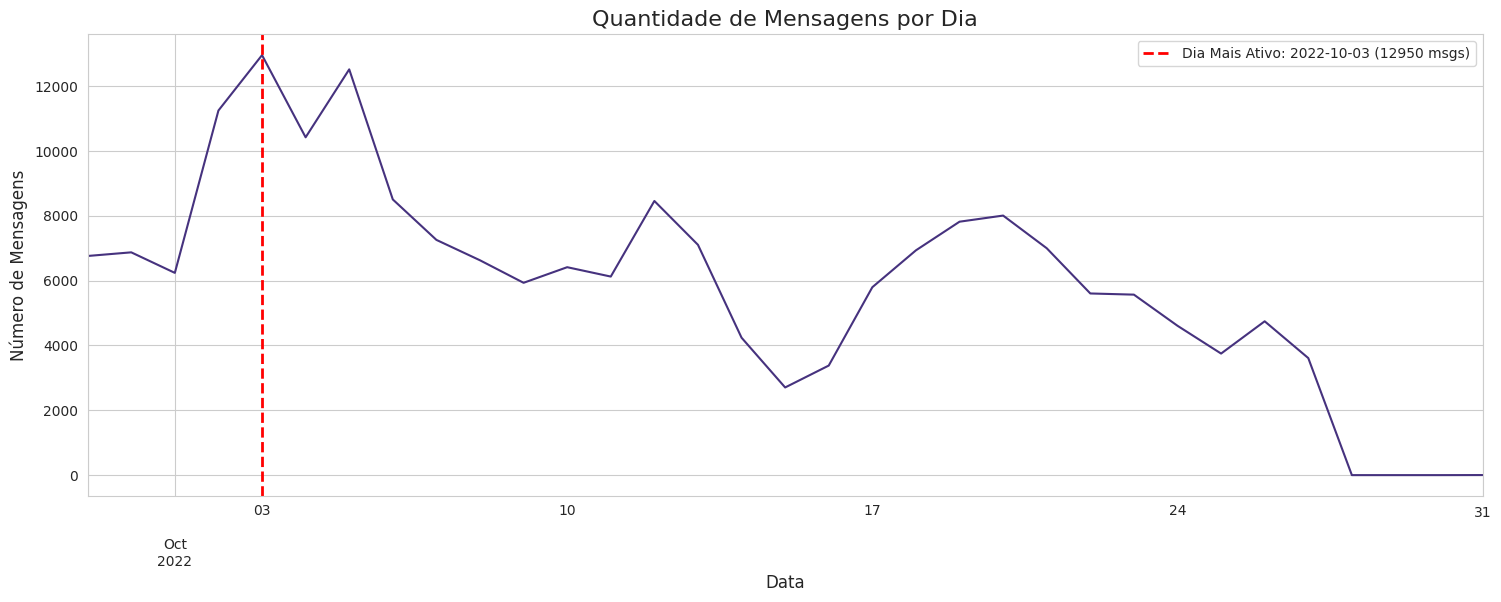

In [54]:
# Célula 27: Mensagens por Dia

# Agrupa por data e conta as mensagens
messages_per_day = df.set_index('date_message').resample('D').size()

plt.figure(figsize=(18, 6))
messages_per_day.plot()
plt.title('Quantidade de Mensagens por Dia', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Número de Mensagens', fontsize=12)

# Destaca o dia com mais mensagens
busiest_day = messages_per_day.idxmax()
max_messages = messages_per_day.max()
plt.axvline(busiest_day, color='red', linestyle='--', lw=2, label=f'Dia Mais Ativo: {busiest_day.date()} ({max_messages} msgs)')
plt.legend()
plt.show()

In [55]:
# Célula 28: Busca por Palavras-Chave

# Filtra mensagens que contêm "facção" OU "criminosa" (ignorando maiúsculas/minúsculas)
keyword_messages = df[df['text_content_anonymous'].str.contains('FACÇÃO|CRIMINOSA', case=False, na=False)]

print(f"Foram encontradas {len(keyword_messages)} mensagens contendo 'facção' ou 'criminosa'.")
print("Amostra das mensagens encontradas:")
print(keyword_messages[['text_content_anonymous']].head(10))

Foram encontradas 546 mensagens contendo 'facção' ou 'criminosa'.
Amostra das mensagens encontradas:
                                                                                                                                     text_content_anonymous
21    Pensem!!!!!!'Se Houve fraude  ,Nada foi feito ,certo?  Nenhuma medida foi tomada para isso tanto pelo governo como FAS ,que se calaram  ,nada decl...
1879  esse desgraçado veta pronunciamento da vacina poliomielite com desculpa que isso fosse beneficiar o presidente na campanha eleitoral, mas permite ...
2370  TSE ORGANIZAÇÃO CRIMINOSA DO PT.... acorda povo... não precisa gosta do presidente Bolsonaro apenas vota a  favor da nossa liberdade que ainda tem...
2929                                                                     o engraçado é que institutos de pesquisas criminosas podem vomitar em cima de nós.
3133  É preciso ter muito cuidado com o Twitter, é um território perigoso, as crianças estão expostas a isso e mesmo pe

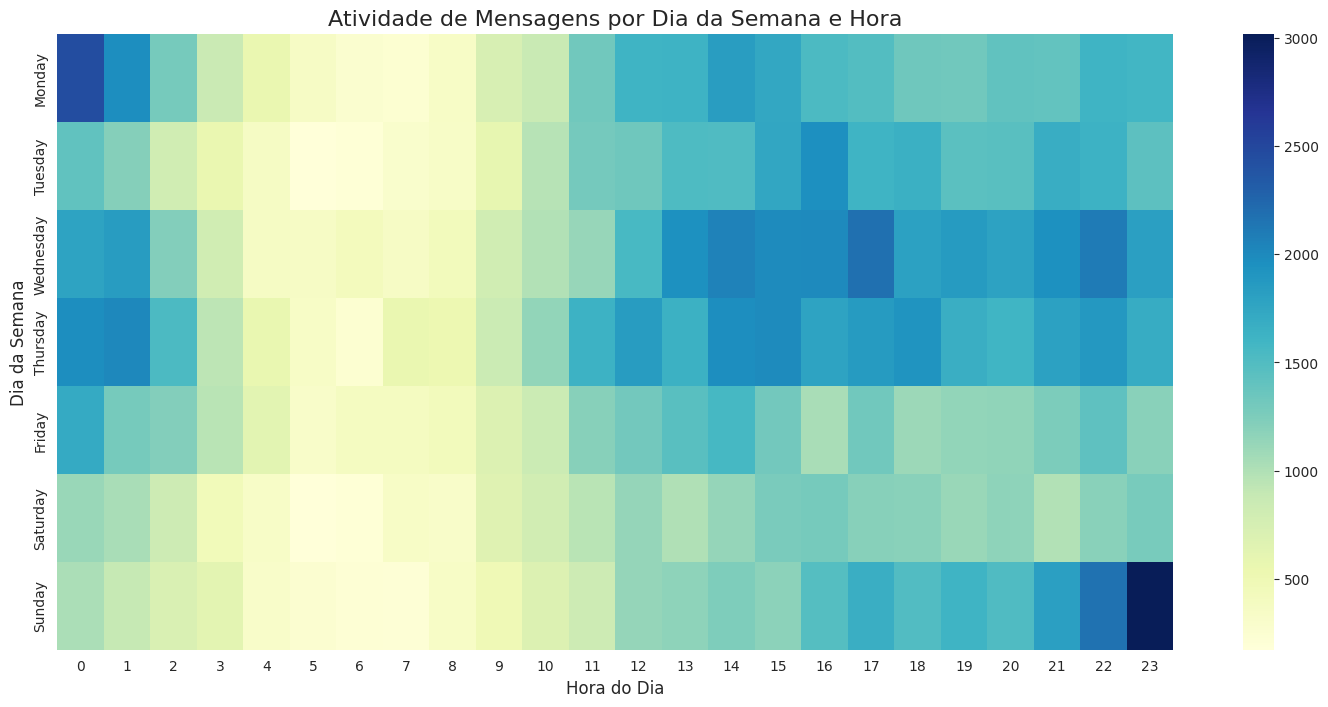

In [56]:
# Célula 29: Heatmap de Atividade por Dia da Semana e Hora

df['hour'] = df['date_message'].dt.hour
df['day_of_week'] = df['date_message'].dt.day_name()

# Cria a tabela de cruzamento
activity_crosstab = pd.crosstab(df['day_of_week'], df['hour'])

# Ordena os dias da semana
ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
activity_crosstab = activity_crosstab.reindex(ordered_days)


plt.figure(figsize=(18, 8))
sns.heatmap(activity_crosstab, cmap="YlGnBu", annot=False)
plt.title('Atividade de Mensagens por Dia da Semana e Hora', fontsize=16)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Dia da Semana', fontsize=12)
plt.show()

/tmp/ipython-input-2466703249.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='plasma')


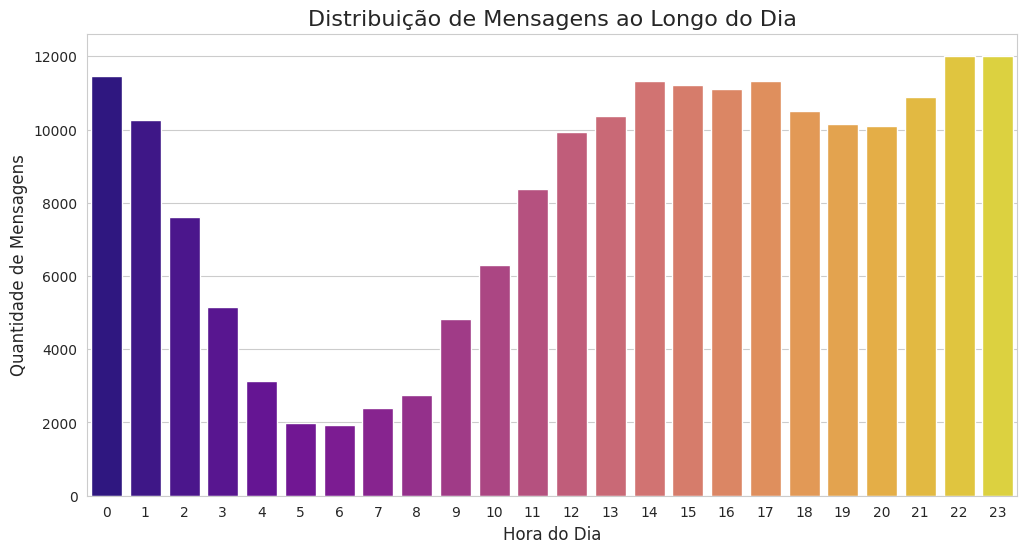

In [57]:
# Célula 30: Mensagens por Hora

plt.figure(figsize=(12, 6))
sns.countplot(x='hour', data=df, palette='plasma')
plt.title('Distribuição de Mensagens ao Longo do Dia', fontsize=16)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Quantidade de Mensagens', fontsize=12)
plt.show()

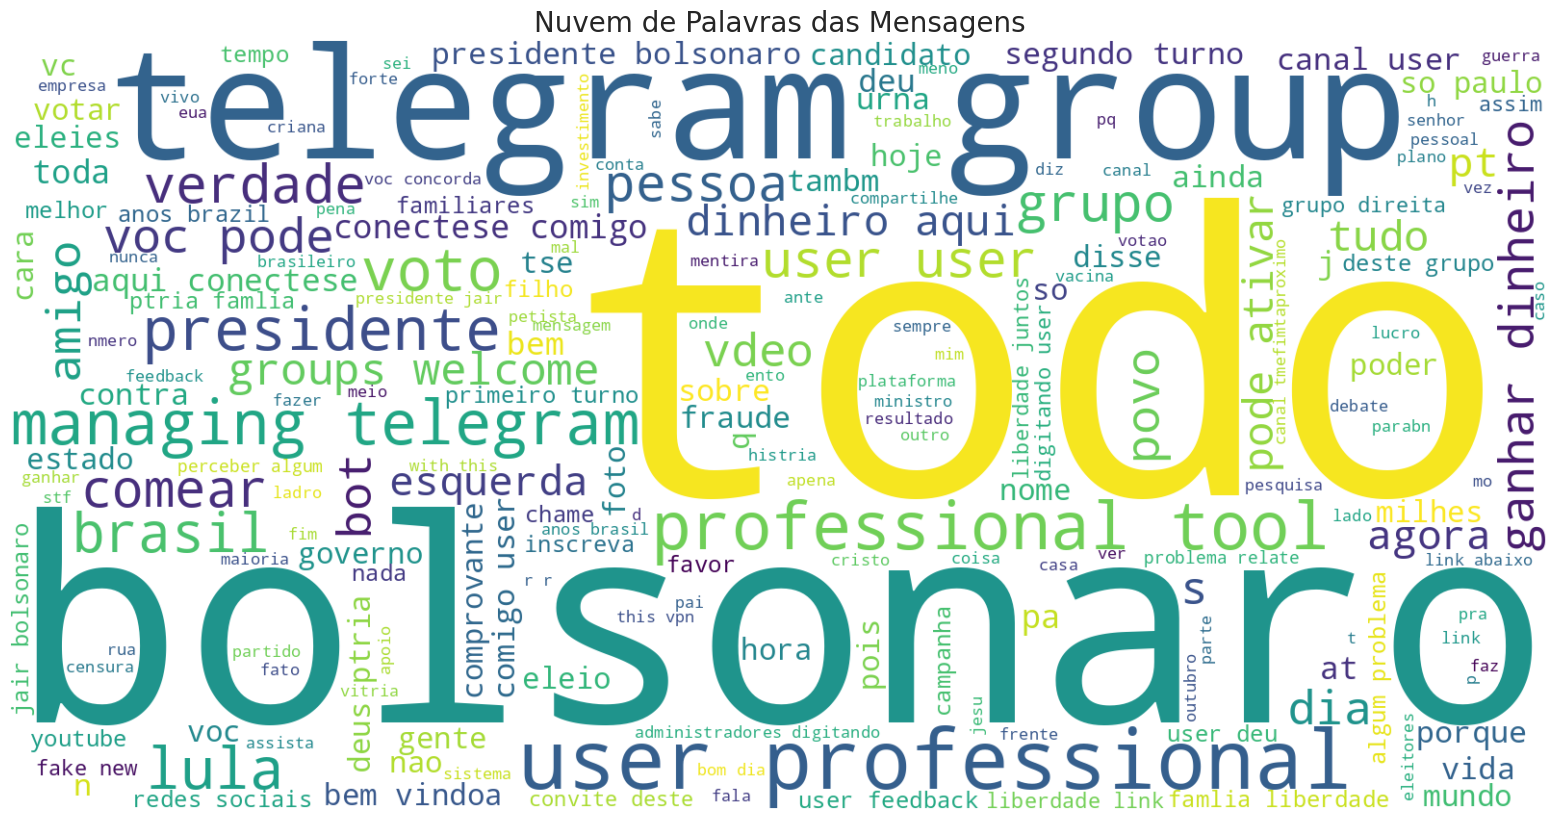

In [58]:
# Célula 31: Nuvem de Palavras

# Usando o corpus processado da célula 20
wordcloud = WordCloud(width=1600, height=800, background_color='white',
                      stopwords=stop_words, max_words=200).generate(corpus)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras das Mensagens', fontsize=20)
plt.show()

In [60]:
# Célula 32: Rede Interativa

# Usando os bigramas da célula 20
top_50_bigrams = Counter(nltk.bigrams(words)).most_common(50)

# Criando o grafo
G = nx.Graph()
for (word1, word2), weight in top_50_bigrams:
    G.add_edge(word1, word2, weight=weight)

# Criando a visualização interativa com Pyvis
net = Network(notebook=True, height="750px", width="100%", bgcolor="#222222", font_color="white")
net.from_nx(G)
net.show_buttons(filter_=['physics'])
net.show("word_network.html")

print("Rede interativa gerada! Abra o arquivo 'word_network.html' que apareceu na lista de arquivos à esquerda.")

word_network.html
Rede interativa gerada! Abra o arquivo 'word_network.html' que apareceu na lista de arquivos à esquerda.


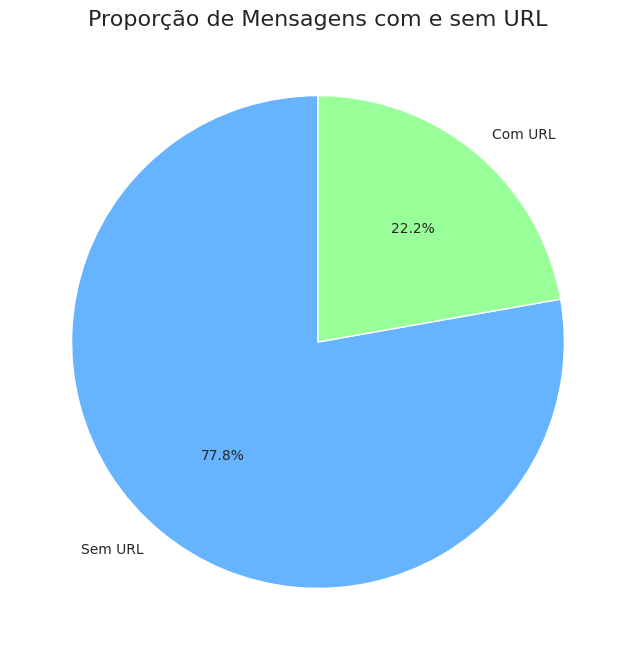

In [61]:
# Célula 33: Proporção de URL

df['has_url'] = df['urls'].apply(lambda x: len(x) > 0)
url_counts = df['has_url'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(url_counts, labels=['Sem URL', 'Com URL'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])
plt.title('Proporção de Mensagens com e sem URL', fontsize=16)
plt.show()

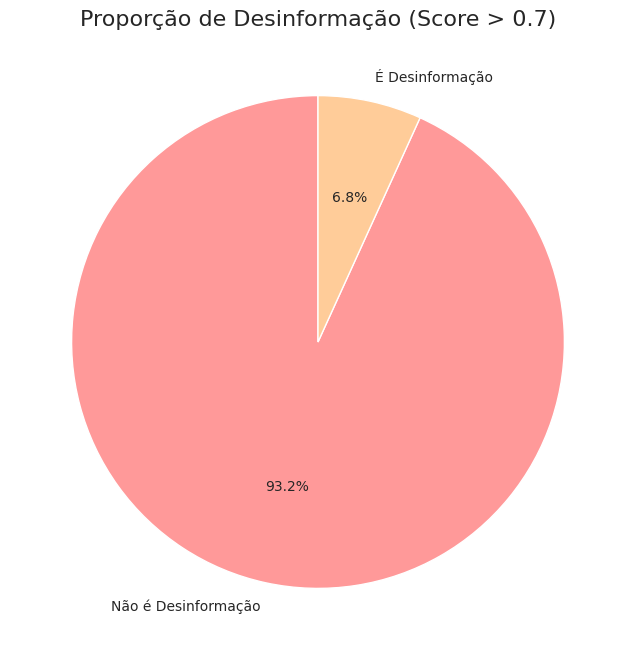

In [62]:
# Célula 34: Proporção de Desinformação

# ASSUMINDO: Consideramos 'desinformação' um score > 0.7
# Este limiar pode ser ajustado conforme a necessidade.
threshold = 0.7
df['is_misinformation'] = df['score_misinformation'] > threshold
misinformation_counts = df['is_misinformation'].value_counts()


plt.figure(figsize=(8, 8))
plt.pie(misinformation_counts, labels=['Não é Desinformação', 'É Desinformação'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#ffcc99'])
plt.title(f'Proporção de Desinformação (Score > {threshold})', fontsize=16)
plt.show()

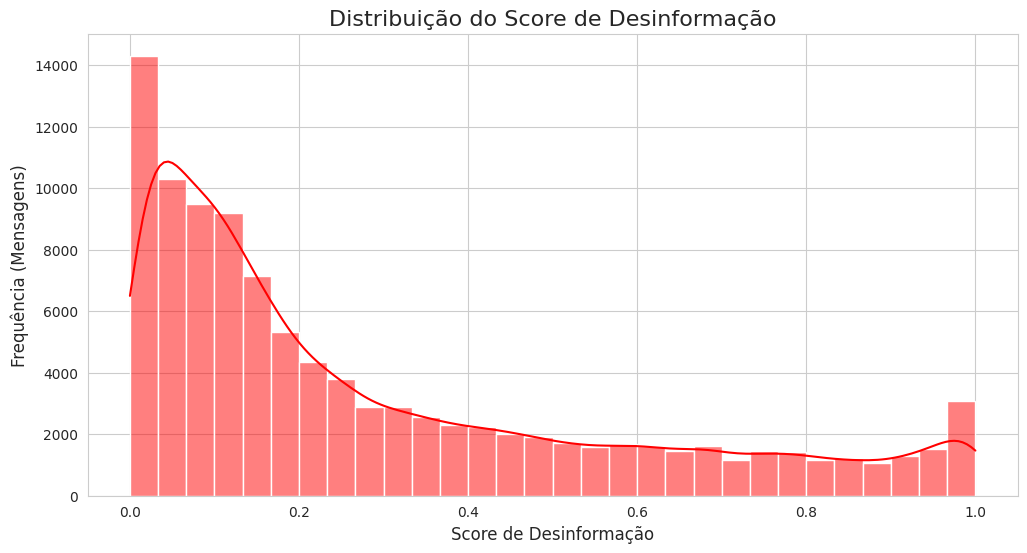

In [63]:
# 36. Distribuição de Mensagens por Score de Desinformação**

# Célula 36: Distribuição do Score de Desinformação

plt.figure(figsize=(12, 6))
sns.histplot(df['score_misinformation'], bins=30, kde=True, color='red')
plt.title('Distribuição do Score de Desinformação', fontsize=16)
plt.xlabel('Score de Desinformação', fontsize=12)
plt.ylabel('Frequência (Mensagens)', fontsize=12)
plt.show()

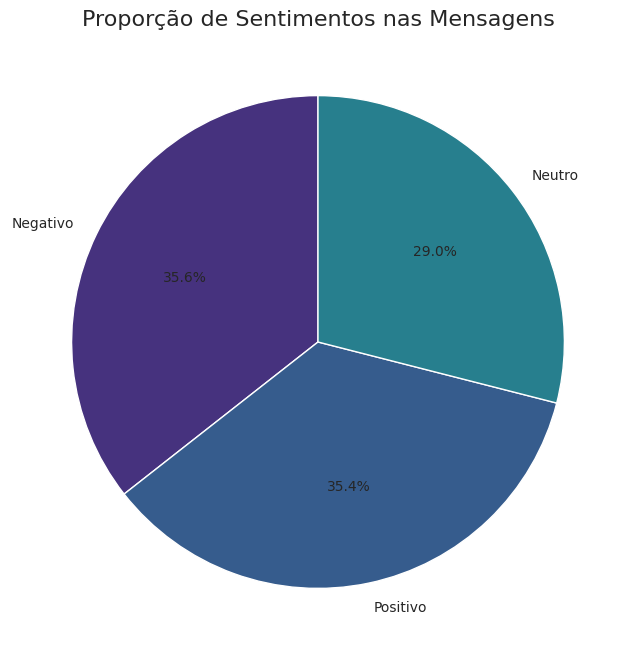

In [64]:
# Célula 37: Proporção de Sentimentos

# ASSUMINDO: Positivo > 0.1, Negativo < -0.1, Neutro entre os dois
def get_sentiment_category(score):
    if score > 0.1:
        return 'Positivo'
    elif score < -0.1:
        return 'Negativo'
    else:
        return 'Neutro'

df['sentiment_category'] = df['score_sentiment'].apply(get_sentiment_category)
sentiment_counts = df['sentiment_category'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proporção de Sentimentos nas Mensagens', fontsize=16)
plt.show()

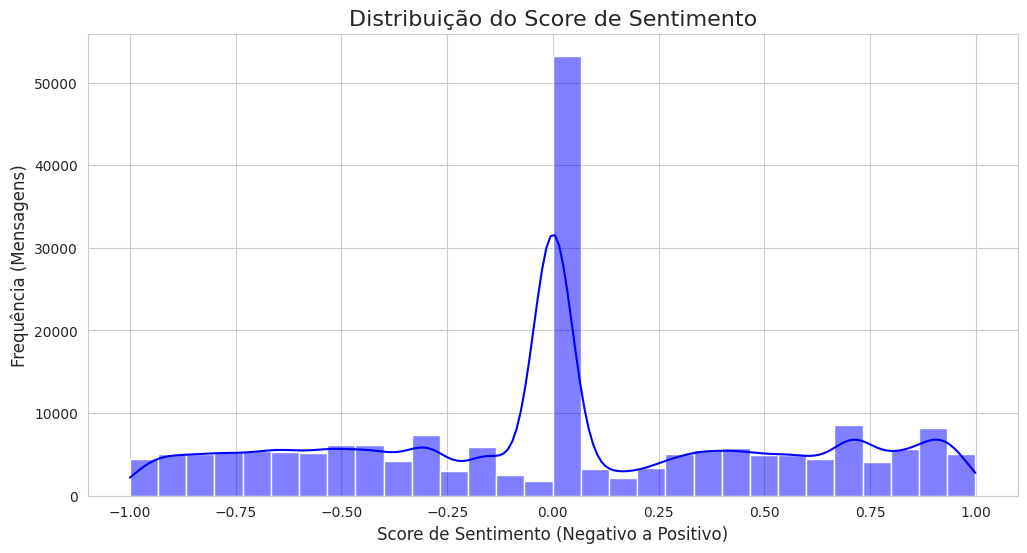

In [65]:
# Célula 38: Distribuição do Score de Sentimento

plt.figure(figsize=(12, 6))
sns.histplot(df['score_sentiment'], bins=30, kde=True, color='blue')
plt.title('Distribuição do Score de Sentimento', fontsize=16)
plt.xlabel('Score de Sentimento (Negativo a Positivo)', fontsize=12)
plt.ylabel('Frequência (Mensagens)', fontsize=12)
plt.show()

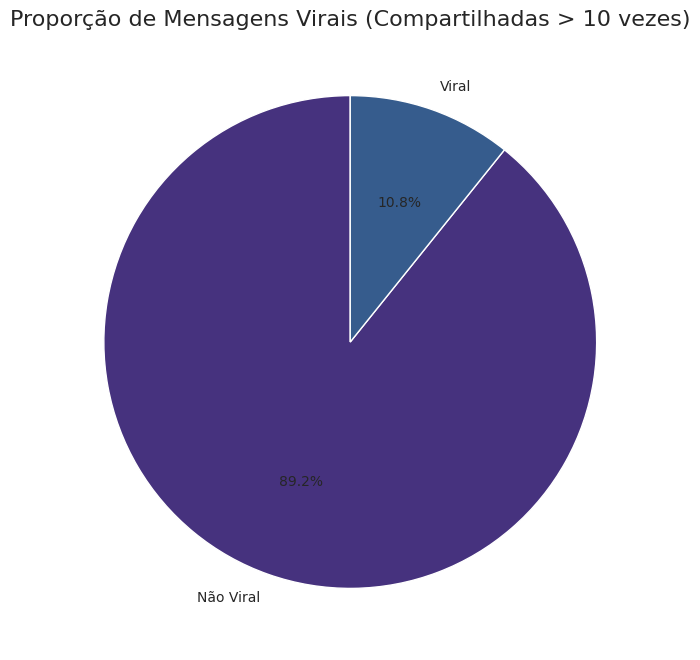

In [66]:
# Célula 39: Mensagens Virais

# ASSUMINDO: Uma mensagem é "viral" se foi compartilhada mais de 10 vezes.
message_counts = df['text_content_anonymous'].value_counts()
viral_threshold = 10
df['is_viral'] = df['text_content_anonymous'].map(message_counts) > viral_threshold
viral_counts = df['is_viral'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(viral_counts, labels=['Não Viral', 'Viral'], autopct='%1.1f%%', startangle=90)
plt.title(f'Proporção de Mensagens Virais (Compartilhadas > {viral_threshold} vezes)', fontsize=16)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127479 (\N{REGIONAL INDICATOR SYMBOL LETTER R}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) m

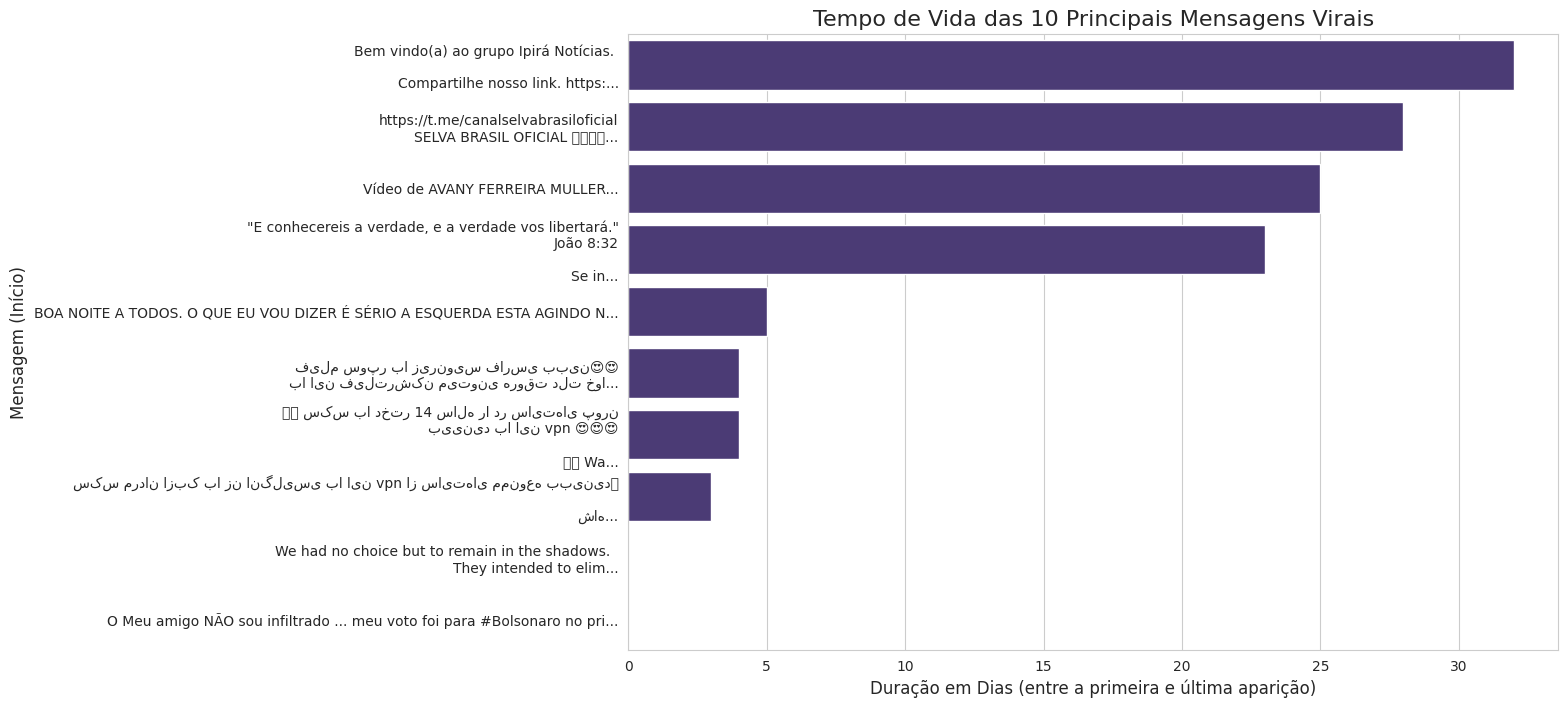

Esta análise mostra por quantos dias as mensagens mais populares continuaram a circular no dataset.


In [67]:
# Célula 40: Tempo de Vida das Mensagens Virais

# Foco nas top 10 mensagens mais virais
top_10_viral_texts = message_counts.head(10).index

# DataFrame para armazenar os resultados
lifespan_data = []

for text in top_10_viral_texts:
    # Filtra as datas para cada mensagem viral
    dates = df[df['text_content_anonymous'] == text]['date_message']
    lifespan = (dates.max() - dates.min()).days  # Duração em dias
    lifespan_data.append({
        'message_start': text[:70] + '...',
        'lifespan_days': lifespan,
        'count': message_counts[text]
    })

lifespan_df = pd.DataFrame(lifespan_data).sort_values('lifespan_days', ascending=False)

# Gráfico
plt.figure(figsize=(12, 8))
ax = sns.barplot(y='message_start', x='lifespan_days', data=lifespan_df, orient='h')
ax.set_title('Tempo de Vida das 10 Principais Mensagens Virais', fontsize=16)
ax.set_xlabel('Duração em Dias (entre a primeira e última aparição)', fontsize=12)
ax.set_ylabel('Mensagem (Início)', fontsize=12)
plt.show()

print("Esta análise mostra por quantos dias as mensagens mais populares continuaram a circular no dataset.")